In [1]:
import copy
import functools
import glob
import pickle
import scipy
import sklearn
import warnings

warnings.filterwarnings('ignore')

import itertools
import graphviz as gr
import numpy as np
import os
import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.api as sm


from matplotlib import style
from matplotlib import pyplot as plt
from pprint import pprint
from scipy import stats, special
from sklearn import datasets, mixture
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm

from urllib.request import urlopen
import json
with urlopen('https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json') as response:
    counties = json.load(response)

import plotly.express as px
import plotly.figure_factory as ff

%matplotlib inline

style.use("fivethirtyeight")
pd.set_option("display.max_columns", 6)

np.random.seed(0)
pd.set_option('display.max_columns', None)

In [2]:
#!pip install --upgrade numpy --user

# File Locations

In [54]:
DATA_FOLDER = "data"
FIGURES_FOLDER = "figures"
OUTPUT_FOLDER = "output"

DATA_FOLDER = os.path.join("..",DATA_FOLDER)
FIGURES_FOLDER = os.path.join("..",FIGURES_FOLDER)
OUTPUT_FOLDER = os.path.join("..",OUTPUT_FOLDER)


# Choose N-th highest growth rate
CHOICE_N = 3

TLGRF_N = "TLGRF" + str(CHOICE_N)
TLGRF_N_FOLDER = os.path.join(OUTPUT_FOLDER,TLGRF_N)
if not os.path.exists(TLGRF_N_FOLDER):
    os.makedirs(TLGRF_N_FOLDER)

ALL_BACKTEST_PATH = os.path.join(DATA_FOLDER,"all_backtest.csv")

In [55]:
ALL_BACKTEST_PATH

'..\\data\\all_backtest.csv'

### Get the actual cases on the day itself `x` from 7 days later `y` data

In [56]:
all_backtest_df = pd.read_csv(ALL_BACKTEST_PATH, parse_dates=True)
#all_backtest_df = all_backtest_df.drop(columns=["r.lm","predicted.lm"])
all_backtest_df["date.y"] = pd.to_datetime(all_backtest_df["date.y"])
all_backtest_df["date.x"] = all_backtest_df["date.y"] +pd.DateOffset(days=-6)
all_backtest_df["date.z"] = all_backtest_df["date.y"] +pd.DateOffset(days=6)

all_backtest_df["days_from_start.x"] = all_backtest_df["days_from_start.y"] - 7
all_backtest_df["days_from_start.z"] = all_backtest_df["days_from_start.y"] + 7


all_backtest_df = all_backtest_df.dropna(subset=["log_rolled_cases.y"])
# Sort by date within each group
all_backtest_df = all_backtest_df.groupby("fips").apply(lambda x: x.sort_values(by="date.y"))
all_backtest_df = all_backtest_df.reset_index(drop=True)

# Shift dates cases back by 7
all_backtest_df["log_rolled_cases.x"] = all_backtest_df.groupby("fips")["log_rolled_cases.y"].shift(7)
all_backtest_df["log_rolled_cases.z"] = all_backtest_df.groupby("fips")["log_rolled_cases.y"].shift(-7)


all_backtest_df = all_backtest_df.dropna(subset=["log_rolled_cases.x"])
all_backtest_df = all_backtest_df.dropna(subset=["log_rolled_cases.z"])
# Find out what's the "ground truth" growth rate
# 7 day fitting window regress log(cases) = r x t + intercept (t [0,6])
#all_backtest_df["r.gt.y"] = (all_backtest_df["log_rolled_cases.y"] - all_backtest_df["log_rolled_cases.x"])/7
all_backtest_df["r.gt.z"] = all_backtest_df["r.gt.y"].shift(-7)


# Get the current rate prediction for date y
#all_backtest_df["r.gt.y"] = all_backtest_df.groupby("fips")["r.gt"].shift(-7)
all_backtest_df["r.grf.y"] = all_backtest_df.groupby("fips")["r.grf"].shift(-7)
all_backtest_df["r.grf.z"] = all_backtest_df.groupby("fips")["r.grf"].shift(-14)

# rename 7 days ago grf estimate to r.grf.x
all_backtest_df["r.grf.x"] = all_backtest_df["r.grf"]

#all_backtest_df["tau.lwr.y"] = all_backtest_df.groupby("fips")["tau.lwr"].shift(-7)
#all_backtest_df["tau.upr.y"] = all_backtest_df.groupby("fips")["tau.upr"].shift(-7)

all_backtest_df = all_backtest_df.dropna(subset=["r.gt.y"])
all_backtest_df = all_backtest_df.dropna(subset=["r.gt.z"])
all_backtest_df = all_backtest_df.dropna(subset=["r.grf.y"])

# Merge with county_fips_master for state
county_fips_master_df = pd.read_csv(os.path.join(OUTPUT_FOLDER,"county_fips_master.csv"))

all_backtest_df = pd.merge(left=all_backtest_df, right = county_fips_master_df[["fips","state_abbr"]],how="left",left_on="fips",right_on="fips")
# add rankings
all_backtest_df["r.gt.z_RANK"] =all_backtest_df.groupby(["date.y","state_abbr"])["r.gt.z"].rank(ascending="False")
all_backtest_df["r.grf.y_RANK"] = all_backtest_df.groupby(["date.y","state_abbr"])["r.grf.y"].rank(ascending="False")


# Add column to see if tau.lwr >= r.gt
#all_backtest_df["test_lwr"] = (all_backtest_df["tau.lwr.y"] >= 0).astype(int)

In [57]:
all_backtest_df

,fips,county,r.lm,predicted.lm,date.y,days_from_start.y,log_rolled_cases.y,r.grf,tau.variance,tau.upr,tau.lwr,predicted.grf,date_delta,r.gt.y,date.x,date.z,days_from_start.x,days_from_start.z,log_rolled_cases.x,log_rolled_cases.z,r.gt.z,r.grf.y,r.grf.z,r.grf.x,state_abbr,r.gt.z_RANK,r.grf.y_RANK
0,10001,Kent,0.130362,4.026048,2020-04-05,75,4.139159,0.165391,0.000147,0.189187,0.141595,4.271254,8.0,0.155766,2020-03-30,2020-04-11,68,82,3.113515,5.484797,0.176907,0.187661,0.086951,0.165391,DE,3.0,3.0
1,10001,Kent,0.085158,3.794778,2020-04-06,76,4.430817,0.132485,0.000105,0.152608,0.112363,4.126070,9.0,0.179872,2020-03-31,2020-04-12,69,83,3.198673,5.556828,0.142212,0.226007,0.074701,0.132485,DE,2.0,3.0
2,10001,Kent,0.124563,4.195175,2020-04-07,77,4.675163,0.150990,0.000112,0.171697,0.130283,4.380167,10.0,0.203947,2020-04-01,2020-04-13,70,84,3.323236,5.643679,0.111514,0.217570,0.078511,0.150990,DE,2.0,3.0
3,10001,Kent,0.134657,4.400491,2020-04-08,78,4.945207,0.148764,0.000148,0.172625,0.124904,4.499244,11.0,0.227909,2020-04-02,2020-04-14,71,85,3.457893,5.715382,0.092487,0.217407,0.069231,0.148764,DE,2.0,3.0
4,10001,Kent,0.132547,4.518266,2020-04-09,79,5.146040,0.141406,0.000035,0.153079,0.129733,4.580281,12.0,0.239206,2020-04-03,2020-04-15,72,86,3.590439,5.765191,0.079980,0.185880,0.051932,0.141406,DE,2.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1237459,99999,New York City,-0.043834,8.508941,2021-06-21,517,8.552705,-0.045972,0.000007,-0.040948,-0.050996,8.493975,450.0,-0.036101,2021-06-15,2021-06-27,510,524,8.815778,8.435766,-0.013409,-0.038238,NaN,-0.045972,NaN,939.0,566.0
1237460,99999,New York City,-0.044718,8.458033,2021-06-22,518,8.523821,-0.047791,0.000010,-0.041628,-0.053955,8.436520,451.0,-0.034657,2021-06-16,2021-06-28,511,525,8.771060,8.415935,-0.012480,-0.034698,NaN,-0.047791,NaN,957.0,620.0
1237461,99999,New York City,-0.041946,8.435493,2021-06-23,519,8.496123,-0.045390,0.000012,-0.038598,-0.052181,8.411386,452.0,-0.033344,2021-06-17,2021-06-29,512,526,8.729114,8.398466,-0.013526,-0.036259,NaN,-0.045390,NaN,937.0,595.0
1237462,99999,New York City,-0.033816,8.458582,2021-06-24,520,8.479595,-0.041391,0.000089,-0.022895,-0.059887,8.405561,453.0,-0.030310,2021-06-18,2021-06-30,513,527,8.695298,8.389133,-0.014445,-0.019052,NaN,-0.041391,NaN,918.0,845.0


In [58]:
#all_backtest_df.groupby(["fips","date.y"])["log_rolled_cases.z"]
all_backtest_df.groupby(["fips","date.y"])["log_rolled_cases.z"]

### Get the Colorado Outbreak Matrix

In [59]:
OUTBREAK_MATRIX_PATH = os.path.join(DATA_FOLDER,"colorado_outbreak_matrix.csv")
outbreak_matrix = pd.read_csv(OUTBREAK_MATRIX_PATH,parse_dates=True, index_col=0)
changepoint_matrix = outbreak_matrix.diff() 

#october_matrix = changepoint_matrix.iloc[198:290]
october_matrix = changepoint_matrix.copy()

nunique = october_matrix.nunique()
cols_to_drop = nunique[nunique == 1].index
october_matrix = october_matrix.drop(cols_to_drop, axis=1)
october_matrix = october_matrix.stack().reset_index(level=[0,1])
october_matrix = october_matrix.rename(columns={"level_0":"date.y","level_1":"fips",0:"changepoint"})
october_matrix

,date.y,fips,changepoint
0,2020-03-18,8001,0.0
1,2020-03-18,8003,0.0
2,2020-03-18,8005,1.0
3,2020-03-18,8007,0.0
4,2020-03-18,8009,0.0
...,...,...,...
28777,2021-09-01,8117,-1.0
28778,2021-09-01,8119,0.0
28779,2021-09-01,8121,0.0
28780,2021-09-01,8123,0.0


In [60]:
#changepoints = pd.DataFrame(october_matrix.idxmax(), columns=["date.y"])
changepoints = october_matrix[october_matrix["changepoint"]==1]
#changepoints["date_outbreak_declared"] = pd.to_datetime(changepoints["date_outbreak_declared"])
changepoints["fips"] = changepoints["fips"].astype(int).to_numpy().flatten()
changepoints["date_outbreak_declared"] = changepoints["date.y"].to_numpy().flatten()
changepoints = changepoints.reset_index()
changepoints = changepoints[["fips","date.y"]]
changepoints

,fips,date.y
0,8005,2020-03-18
1,8013,2020-03-19
2,8015,2020-03-20
3,8001,2020-03-23
4,8059,2020-03-23
...,...,...
142,8093,2021-07-20
143,8123,2021-07-31
144,8043,2021-08-04
145,8014,2021-08-09


### If `tau.lwr >= r.gt`

In [61]:
DD_list = [7,14,21,28]
r_DD = np.log(2)/DD_list
r_DD

array([0.09902103, 0.04951051, 0.03300701, 0.02475526])

In [62]:
presented_df = all_backtest_df.copy()
# Restrict to Colorado
presented_df = presented_df[presented_df["fips"].isin(outbreak_matrix.columns.astype(int)) ]
#presented_df = presented_df.drop(columns=["fips","log_rolled_cases.x","days_from_start.x","days_from_start.y","date.y","tau.variance"])
presented_df["cases.y"] = np.exp(presented_df["log_rolled_cases.y"])
presented_df["cases.x"] = np.exp(presented_df["log_rolled_cases.x"])
presented_df["grf_predicted.y"] = np.exp(presented_df["predicted.grf"])

reordered_cols = ["date.y", "fips", "county", "cases.x", "grf_predicted.y", "cases.y", "r.grf.x","r.grf.y","r.gt.y","r.gt.z", "r.grf.y_RANK","r.gt.z_RANK"]
#reordered_cols += ["r.lm","predicted.lm"]
#reordred_cols += ["tau.lwr.y", "tau.upr.y", "test_lwr"]
presented_df = presented_df[reordered_cols]

### Generate table to see if we managed to predict outbreaks at changepoints

In [63]:
display_df = pd.merge(presented_df, changepoints, how='inner', left_on=["fips","date.y"], right_on=["fips","date.y"])
#display_df = display_df.sort_values(by=["date.y","fips"])
#display_df = display_df.sort_values(by=["test_lwr","date.y","fips"])
display_df = display_df.sort_values(by=["date.y","fips"])
display_df["DD.gt.y"] = np.log(2)/display_df["r.gt.y"]
negative_DD_mask = display_df["DD.gt.y"] <= 0 
display_df.loc[negative_DD_mask,"DD.gt.y"] = np.inf
#display_df["predicted.lm.y"] = np.exp(display_df["predicted.lm"] )
display_df.to_csv(os.path.join(DATA_FOLDER,"changepoint_df.csv"), index=False)
changepoints_list = display_df[["date.y","fips","r.grf.y"]]

display_df

,date.y,fips,county,cases.x,grf_predicted.y,cases.y,r.grf.x,r.grf.y,r.gt.y,r.gt.z,r.grf.y_RANK,r.gt.z_RANK,DD.gt.y
51,2020-04-09,8051,Gunnison,82.00,121.220063,86.25,0.055841,0.018593,0.006117,-0.042100,2.0,2.0,113.322329
14,2020-04-21,8014,Broomfield,79.75,113.303702,86.75,0.050168,-0.013216,0.005868,0.015494,21.0,28.0,118.122383
103,2020-04-28,8117,Summit,75.50,84.609395,64.25,0.016273,0.009246,-0.024458,0.024314,25.0,35.0,inf
0,2020-05-06,8003,Alamosa,6.00,6.303812,8.50,0.007056,0.162686,0.053793,0.102925,40.0,39.0,12.885573
36,2020-05-08,8037,Eagle,171.25,119.424692,81.00,-0.051491,-0.059162,-0.111846,-0.002923,4.0,26.0,inf
...,...,...,...,...,...,...,...,...,...,...,...,...,...
35,2021-06-07,8029,Delta,80.00,58.261175,66.25,-0.045299,-0.052523,-0.026291,0.044084,21.0,56.0,inf
71,2021-06-07,8081,Moffat,56.00,68.252772,99.00,0.028267,0.047990,0.094412,0.023414,56.0,53.0,7.341706
55,2021-06-16,8051,Gunnison,16.25,22.924956,22.50,0.049162,0.023823,0.031129,0.034658,50.0,54.0,22.266932
8,2021-06-22,8007,Archuleta,34.50,30.791855,31.25,-0.016244,0.007964,-0.015227,-0.060110,47.0,12.0,inf


### Stage 1: If State was consistent decision maker, what was the threshold for each changepoint (lowest `r` if multiple changepoints on the same day)

In [64]:
unique_changepoints = changepoints_list["date.y"].unique()
r_thresh_list = changepoints_list.groupby("date.y")["r.grf.y"].min()
cp_df = pd.DataFrame({"date.y":unique_changepoints, "r.thresh.y":r_thresh_list.values})
cp_df

,date.y,r.thresh.y
0,2020-04-09,0.018593
1,2020-04-21,-0.013216
2,2020-04-28,0.009246
3,2020-05-06,0.162686
4,2020-05-08,-0.059162
...,...,...
90,2021-06-04,-0.059288
91,2021-06-07,-0.052523
92,2021-06-16,0.023823
93,2021-06-22,0.007964


In [65]:
# How many under investigation already? (Black) 1
# How many changepoints (Started Investigation) 2
# How many that ought to have been investigated given consistent decision (False White) 3
# How many that are OK (True White) 4

outbreak_df = outbreak_matrix.stack().reset_index(level=[0,1])
outbreak_df = outbreak_df.rename(columns={"level_0":"date.y", "level_1":"fips", 0: "colour"})
outbreak_df = outbreak_df[outbreak_df["date.y"].isin(unique_changepoints)]
outbreak_df["fips"] = outbreak_df["fips"].astype(np.int64)
outbreak_df

,date.y,fips,colour
1242,2020-04-09,8001,1
1243,2020-04-09,8003,0
1244,2020-04-09,8005,1
1245,2020-04-09,8007,0
1246,2020-04-09,8009,0
...,...,...,...
25105,2021-06-24,8117,0
25106,2021-06-24,8119,1
25107,2021-06-24,8121,0
25108,2021-06-24,8123,1


In [66]:
# Join with display_df to get the 4 classes
stage1_df = pd.merge(left=all_backtest_df,right=outbreak_df, how="inner", on=["date.y","fips"])
stage1_df = pd.merge(left=stage1_df,right=cp_df, how="left", on=["date.y"])
stage1_cols = ["date.y", "fips", "county", "r.grf.x","r.grf.y","r.gt.z","r.grf.y_RANK","r.gt.z_RANK","r.thresh.y","colour", "log_rolled_cases.y"]
stage1_df = stage1_df[stage1_cols]
# Get the true colours 
# How many under investigation already? (Black) 1
# How many changepoints (Started Investigation) 2
# How many that ought to have been investigated given consistent decision (False White) 3
# How many that are OK (True White) 0
cp_list = changepoints_list[["date.y","fips"]]
cp_list["cp"] = 1
# get colour = 2
# Don't merge, loc and set cp
stage1_df = pd.merge(left=stage1_df, right=cp_list, how="left", on=["date.y","fips"])
# replace NaN with 0 on "cp"
stage1_df["cp"]=stage1_df["cp"].fillna(0)
stage1_df["cp"] = stage1_df["cp"].astype(np.int64)

stage1_df["true_colour"] = stage1_df["colour"] 
stage1_df["true_colour"] +=  stage1_df["cp"]

mask3 = (stage1_df["colour"] == 0) & (stage1_df["r.grf.y"] > stage1_df["r.thresh.y"])
stage1_df.loc[mask3,"true_colour"] = 3

# Not under investigation in future but >= threshold
future_mask = (stage1_df["r.gt.z"] > stage1_df["r.thresh.y"]) & (stage1_df["true_colour"].isin([3]))

stage1_df["future_red"] = future_mask.copy().astype(np.int64)

stage1_df["r.grf.y_RANK"] = stage1_df.groupby("date.y")["r.grf.y"].rank(ascending=False)
stage1_df["r.gt.z_RANK"] = stage1_df.groupby("date.y")["r.gt.z"].rank(ascending=False)

stage1_df

,date.y,fips,county,r.grf.x,r.grf.y,r.gt.z,r.grf.y_RANK,r.gt.z_RANK,r.thresh.y,colour,log_rolled_cases.y,cp,true_colour,future_red
0,2020-04-09,8001,Adams,0.190322,0.071774,0.079653,4.0,3.0,0.018593,1,5.999557,0,1,0
1,2020-04-21,8001,Adams,0.061408,0.017410,0.037692,12.0,9.0,-0.013216,1,6.728629,0,1,0
2,2020-04-28,8001,Adams,0.017410,0.019223,0.019314,12.0,11.0,0.009246,1,6.941190,0,1,0
3,2020-05-06,8001,Adams,0.024113,0.012520,0.018611,14.0,7.0,0.162686,1,7.084017,0,1,0
4,2020-05-08,8001,Adams,0.030420,0.026854,0.011617,8.0,8.0,-0.059162,1,7.134094,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4347,2021-06-04,8125,Yuma,-0.013355,0.011323,0.005268,13.0,10.0,-0.059288,1,3.725693,0,1,0
4348,2021-06-07,8125,Yuma,-0.038475,0.015689,-0.016421,7.0,21.0,-0.052523,1,3.772761,0,1,0
4349,2021-06-16,8125,Yuma,-0.014025,-0.027019,-0.048216,29.0,37.0,0.023823,1,3.663562,0,1,0
4350,2021-06-22,8125,Yuma,-0.017605,-0.026606,-0.117736,30.0,46.0,0.007964,1,3.384390,0,1,0


In [67]:
stage1_df[stage1_df["county"]=="Alamosa"]

,date.y,fips,county,r.grf.x,r.grf.y,r.gt.z,r.grf.y_RANK,r.gt.z_RANK,r.thresh.y,colour,log_rolled_cases.y,cp,true_colour,future_red
95,2020-04-21,8003,Alamosa,0.013911,0.030436,-0.043152,8.0,28.0,-0.013216,0,1.945910,0,3,0
96,2020-04-28,8003,Alamosa,0.030436,0.003763,-0.024011,19.0,28.0,0.009246,0,1.791759,0,0,0
97,2020-05-06,8003,Alamosa,0.007056,0.162686,0.102925,1.0,1.0,0.162686,1,2.140066,1,2,0
98,2020-05-08,8003,Alamosa,-0.097532,0.161362,0.074210,1.0,1.0,-0.059162,1,2.674149,0,1,0
99,2020-05-21,8003,Alamosa,0.098101,0.080105,0.026516,3.0,12.0,-0.051815,1,3.548180,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
184,2021-06-04,8003,Alamosa,0.007935,-0.046312,-0.060613,38.0,44.0,-0.059288,1,5.023881,0,1,0
185,2021-06-07,8003,Alamosa,-0.035461,-0.058610,-0.069717,36.0,45.0,-0.052523,1,4.836282,0,1,0
186,2021-06-16,8003,Alamosa,-0.055129,-0.064224,-0.110529,47.0,48.0,0.023823,1,4.215824,0,1,0
187,2021-06-22,8003,Alamosa,-0.064479,-0.072572,-0.057697,45.0,39.0,0.007964,1,3.533687,0,1,0


In [68]:
test_future_red = np.zeros(stage1_df.shape[0])
for i,d in enumerate(cp_df["date.y"]):
    dmask = stage1_df["date.y"] == d
    thresh = cp_df.loc[i,"r.thresh.y"]
    cp_indx = (stage1_df["r.grf.y"] == thresh)
    more_serious = (stage1_df["r.gt.z"] > stage1_df[cp_indx]["r.gt.z"].min()) & (stage1_df["true_colour"]==3)
    test_future_red[dmask] = more_serious[dmask]
    

In [69]:
np.sum(test_future_red)

288.0

In [70]:
# x-axis = date.y
# y-axis = different colour classes
tc_counts = stage1_df.groupby("date.y")["true_colour"].value_counts().unstack(fill_value=0).stack()
tc_counts_df = tc_counts.reset_index(level=[0,1])
tc_counts_df = tc_counts_df.rename(columns={0:"count"})
tc_counts_df

,date.y,true_colour,count
0,2020-04-09,0,1
1,2020-04-09,1,14
2,2020-04-09,2,1
3,2020-04-09,3,6
4,2020-04-21,0,10
...,...,...,...
375,2021-06-22,3,6
376,2021-06-24,0,9
377,2021-06-24,1,23
378,2021-06-24,2,1


### Plot Stage 1: Note that they don't sum up to 54 at points due to missing data / not enough data to make an accurate rate estimate

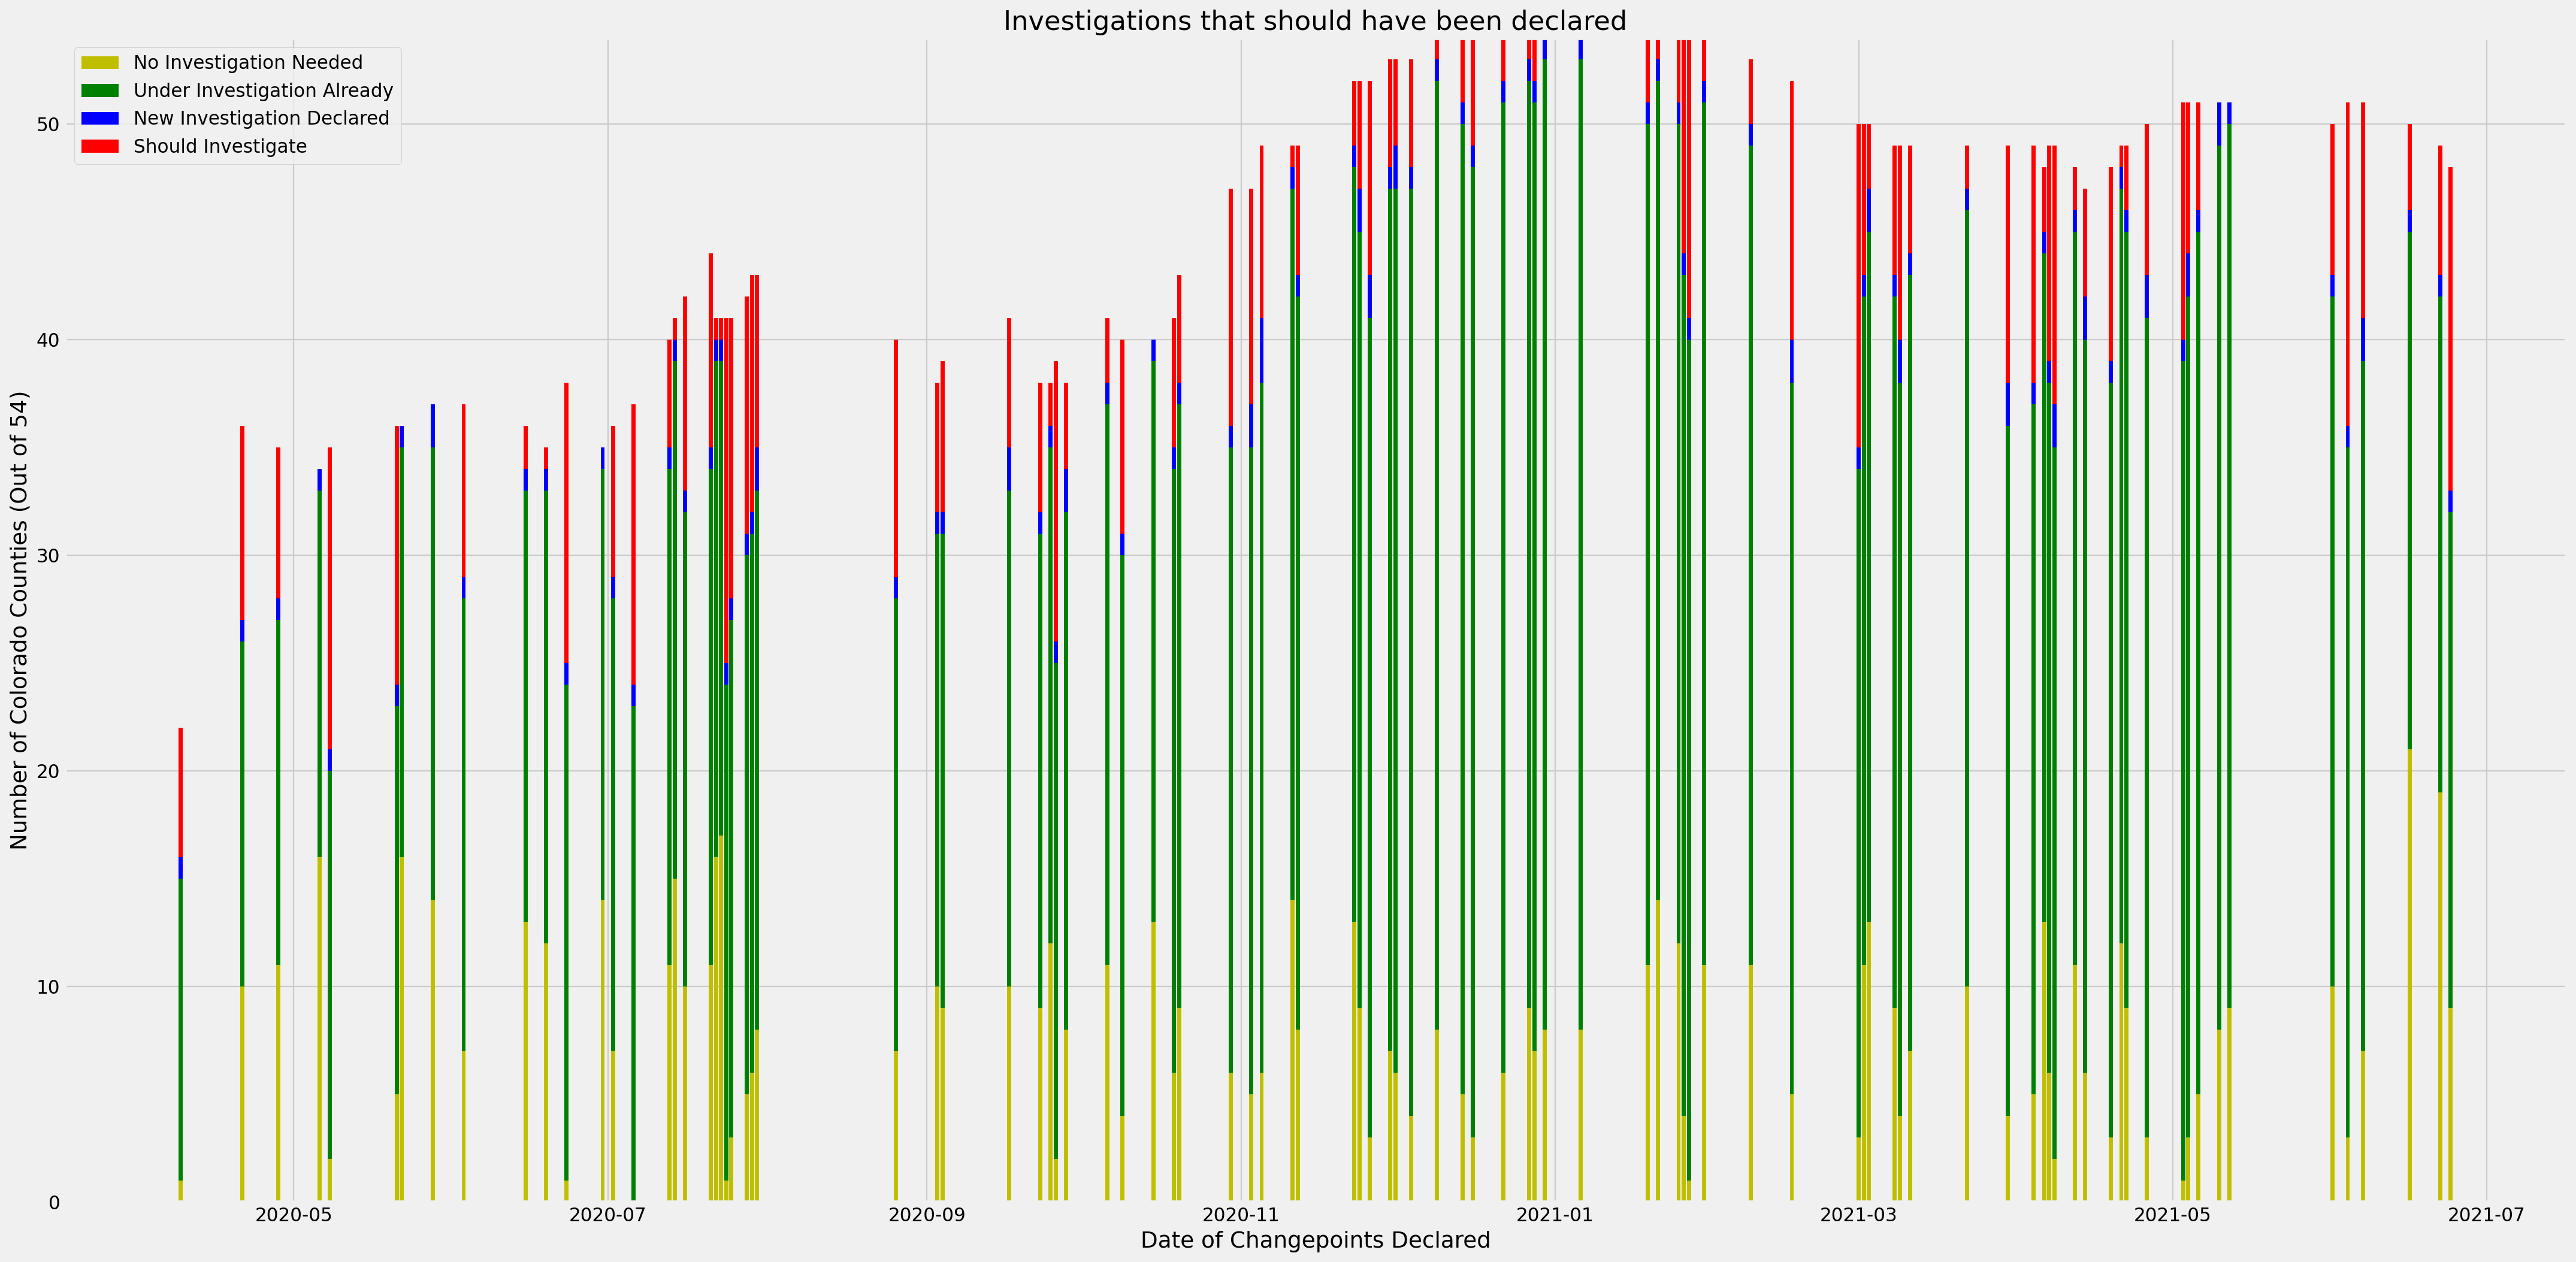

In [71]:
yarr = tc_counts.values.reshape(len(tc_counts)//4,4).T
xarr = unique_changepoints

plt.figure(figsize=(30, 15), dpi=160)
plt.bar(xarr, yarr[0], color = "y")
plt.bar(xarr, yarr[1], bottom = yarr[0], color = "g")
plt.bar(xarr, yarr[2], bottom = yarr[0] + yarr[1], color = "b")
plt.bar(xarr, yarr[3], bottom = yarr[0] + yarr[1] + yarr[2], color = "r")
plt.ylim(top=54)
plt.legend(["No Investigation Needed", "Under Investigation Already", "New Investigation Declared", "Should Investigate"])
plt.ylabel("Number of Colorado Counties (Out of 54)")
plt.xlabel("Date of Changepoints Declared")
plt.title("Investigations that should have been declared")
plt.savefig(os.path.join(FIGURES_FOLDER,"stage1_plot.png"))

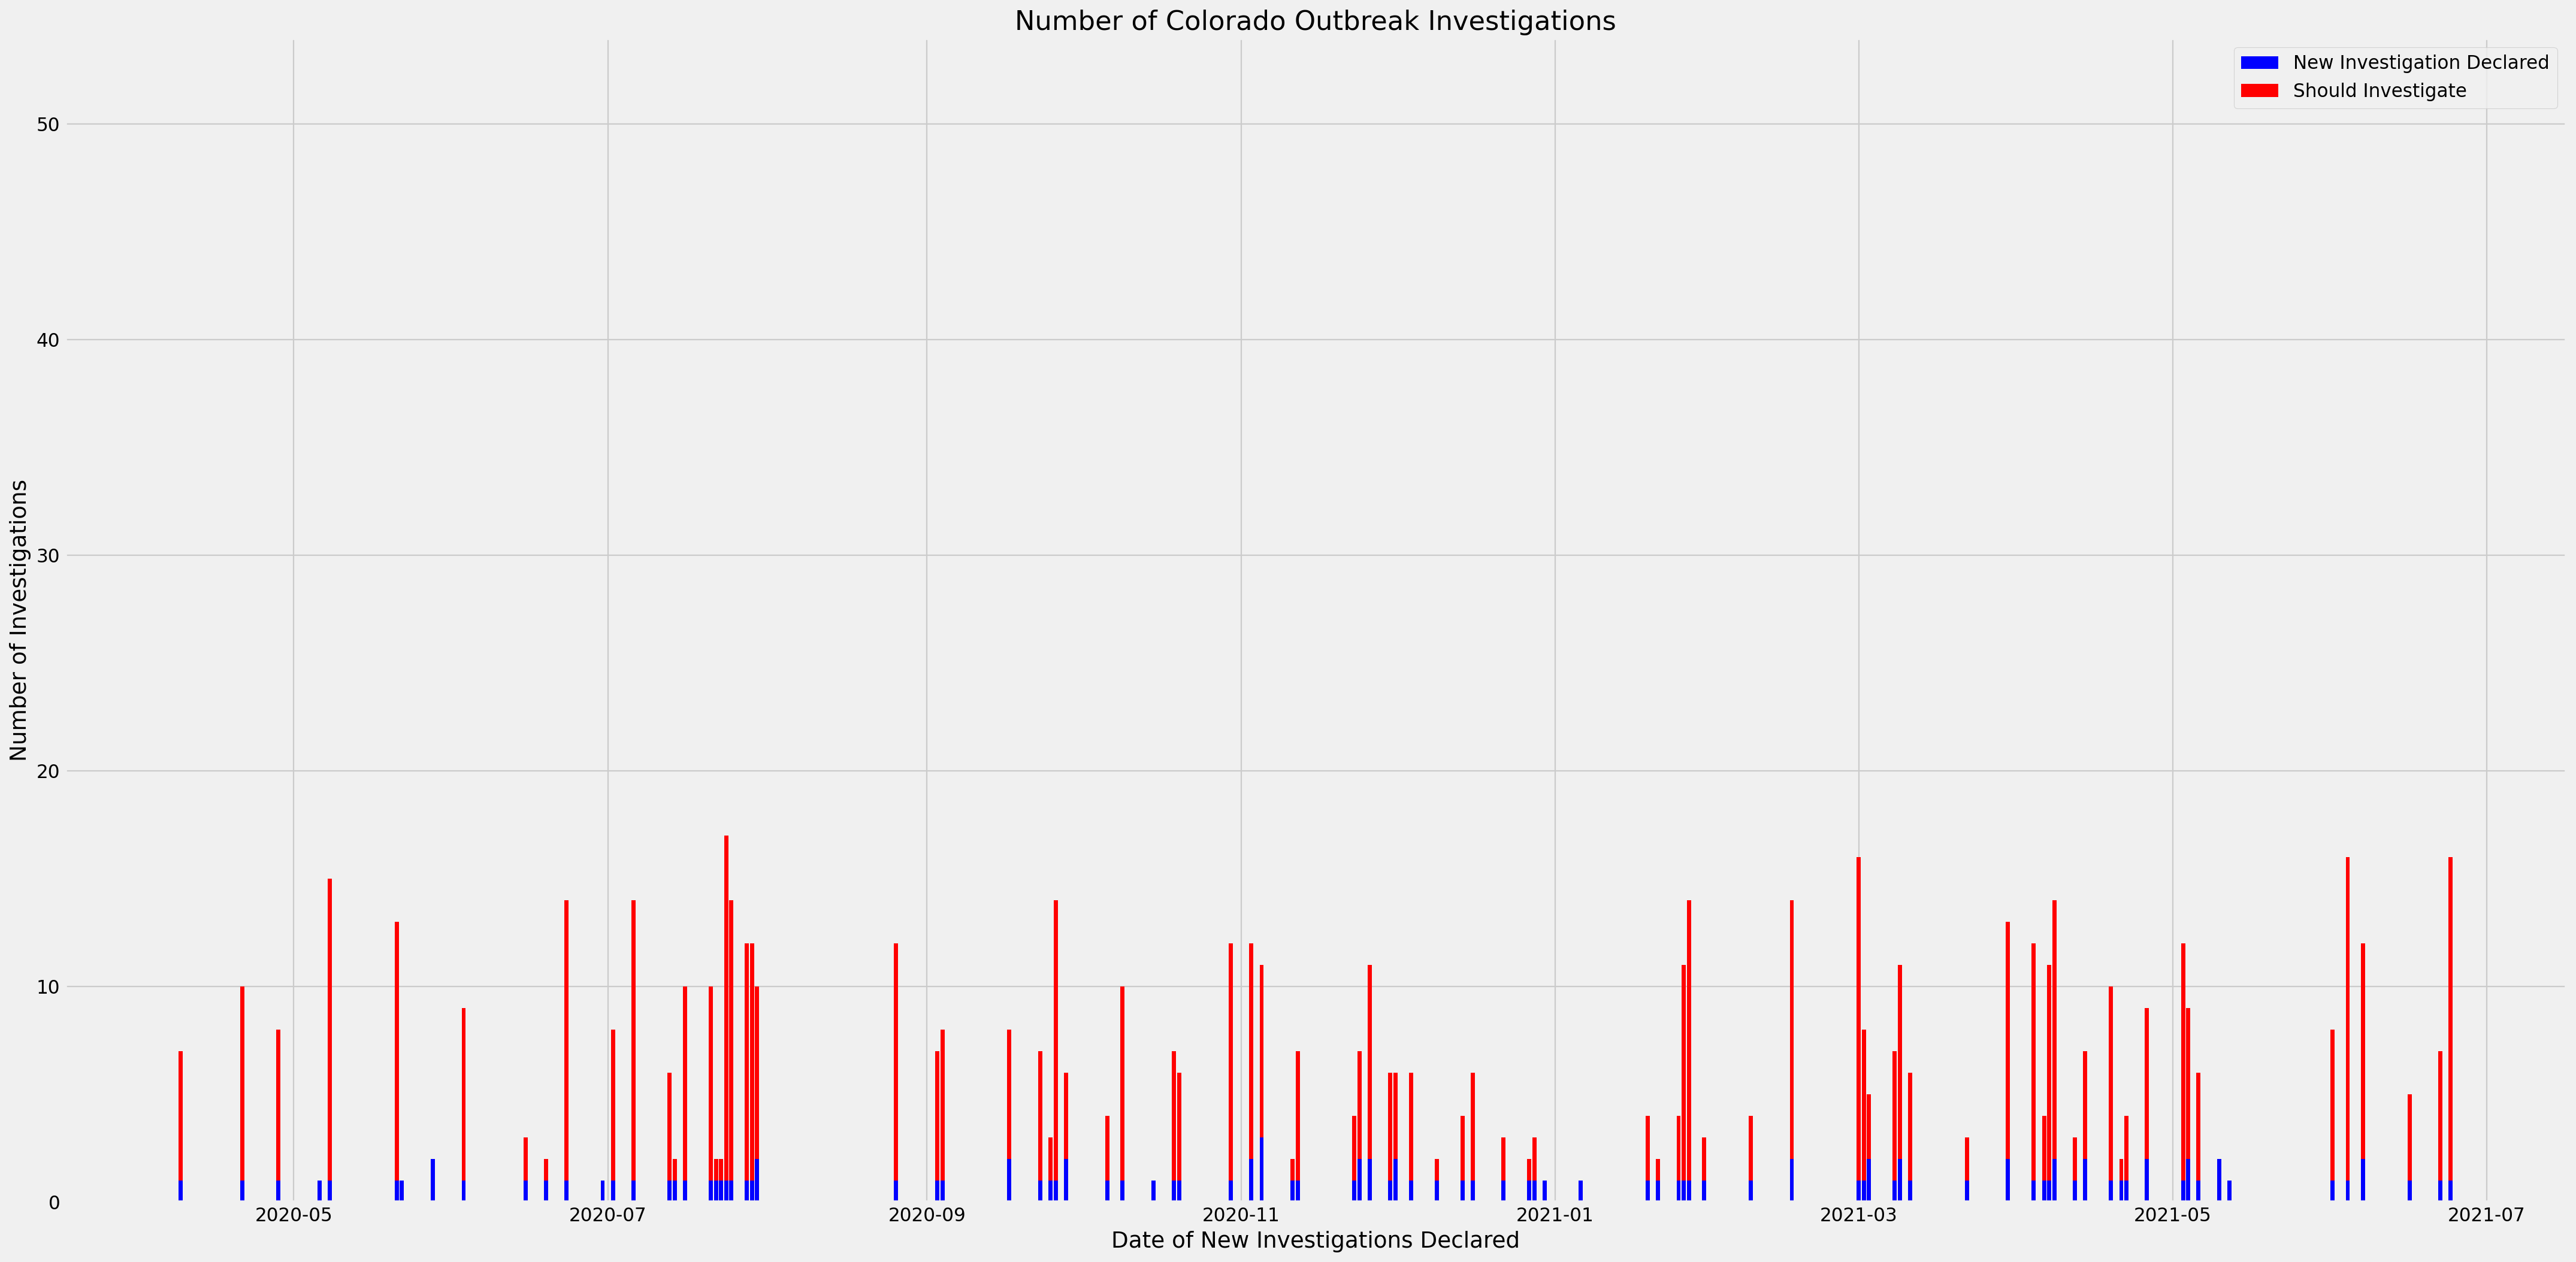

In [72]:
plt.figure(figsize=(30, 15), dpi=160)
plt.bar(xarr, yarr[2], color = "b")
plt.bar(xarr, yarr[3], bottom = yarr[2], color = "r")
plt.ylim(top=54)

plt.legend(["New Investigation Declared", "Should Investigate"])
plt.ylabel("Number of Investigations")
plt.xlabel("Date of New Investigations Declared")
plt.title("Number of Colorado Outbreak Investigations")
plt.savefig(os.path.join(FIGURES_FOLDER,"stage1_plot_rb.png"))

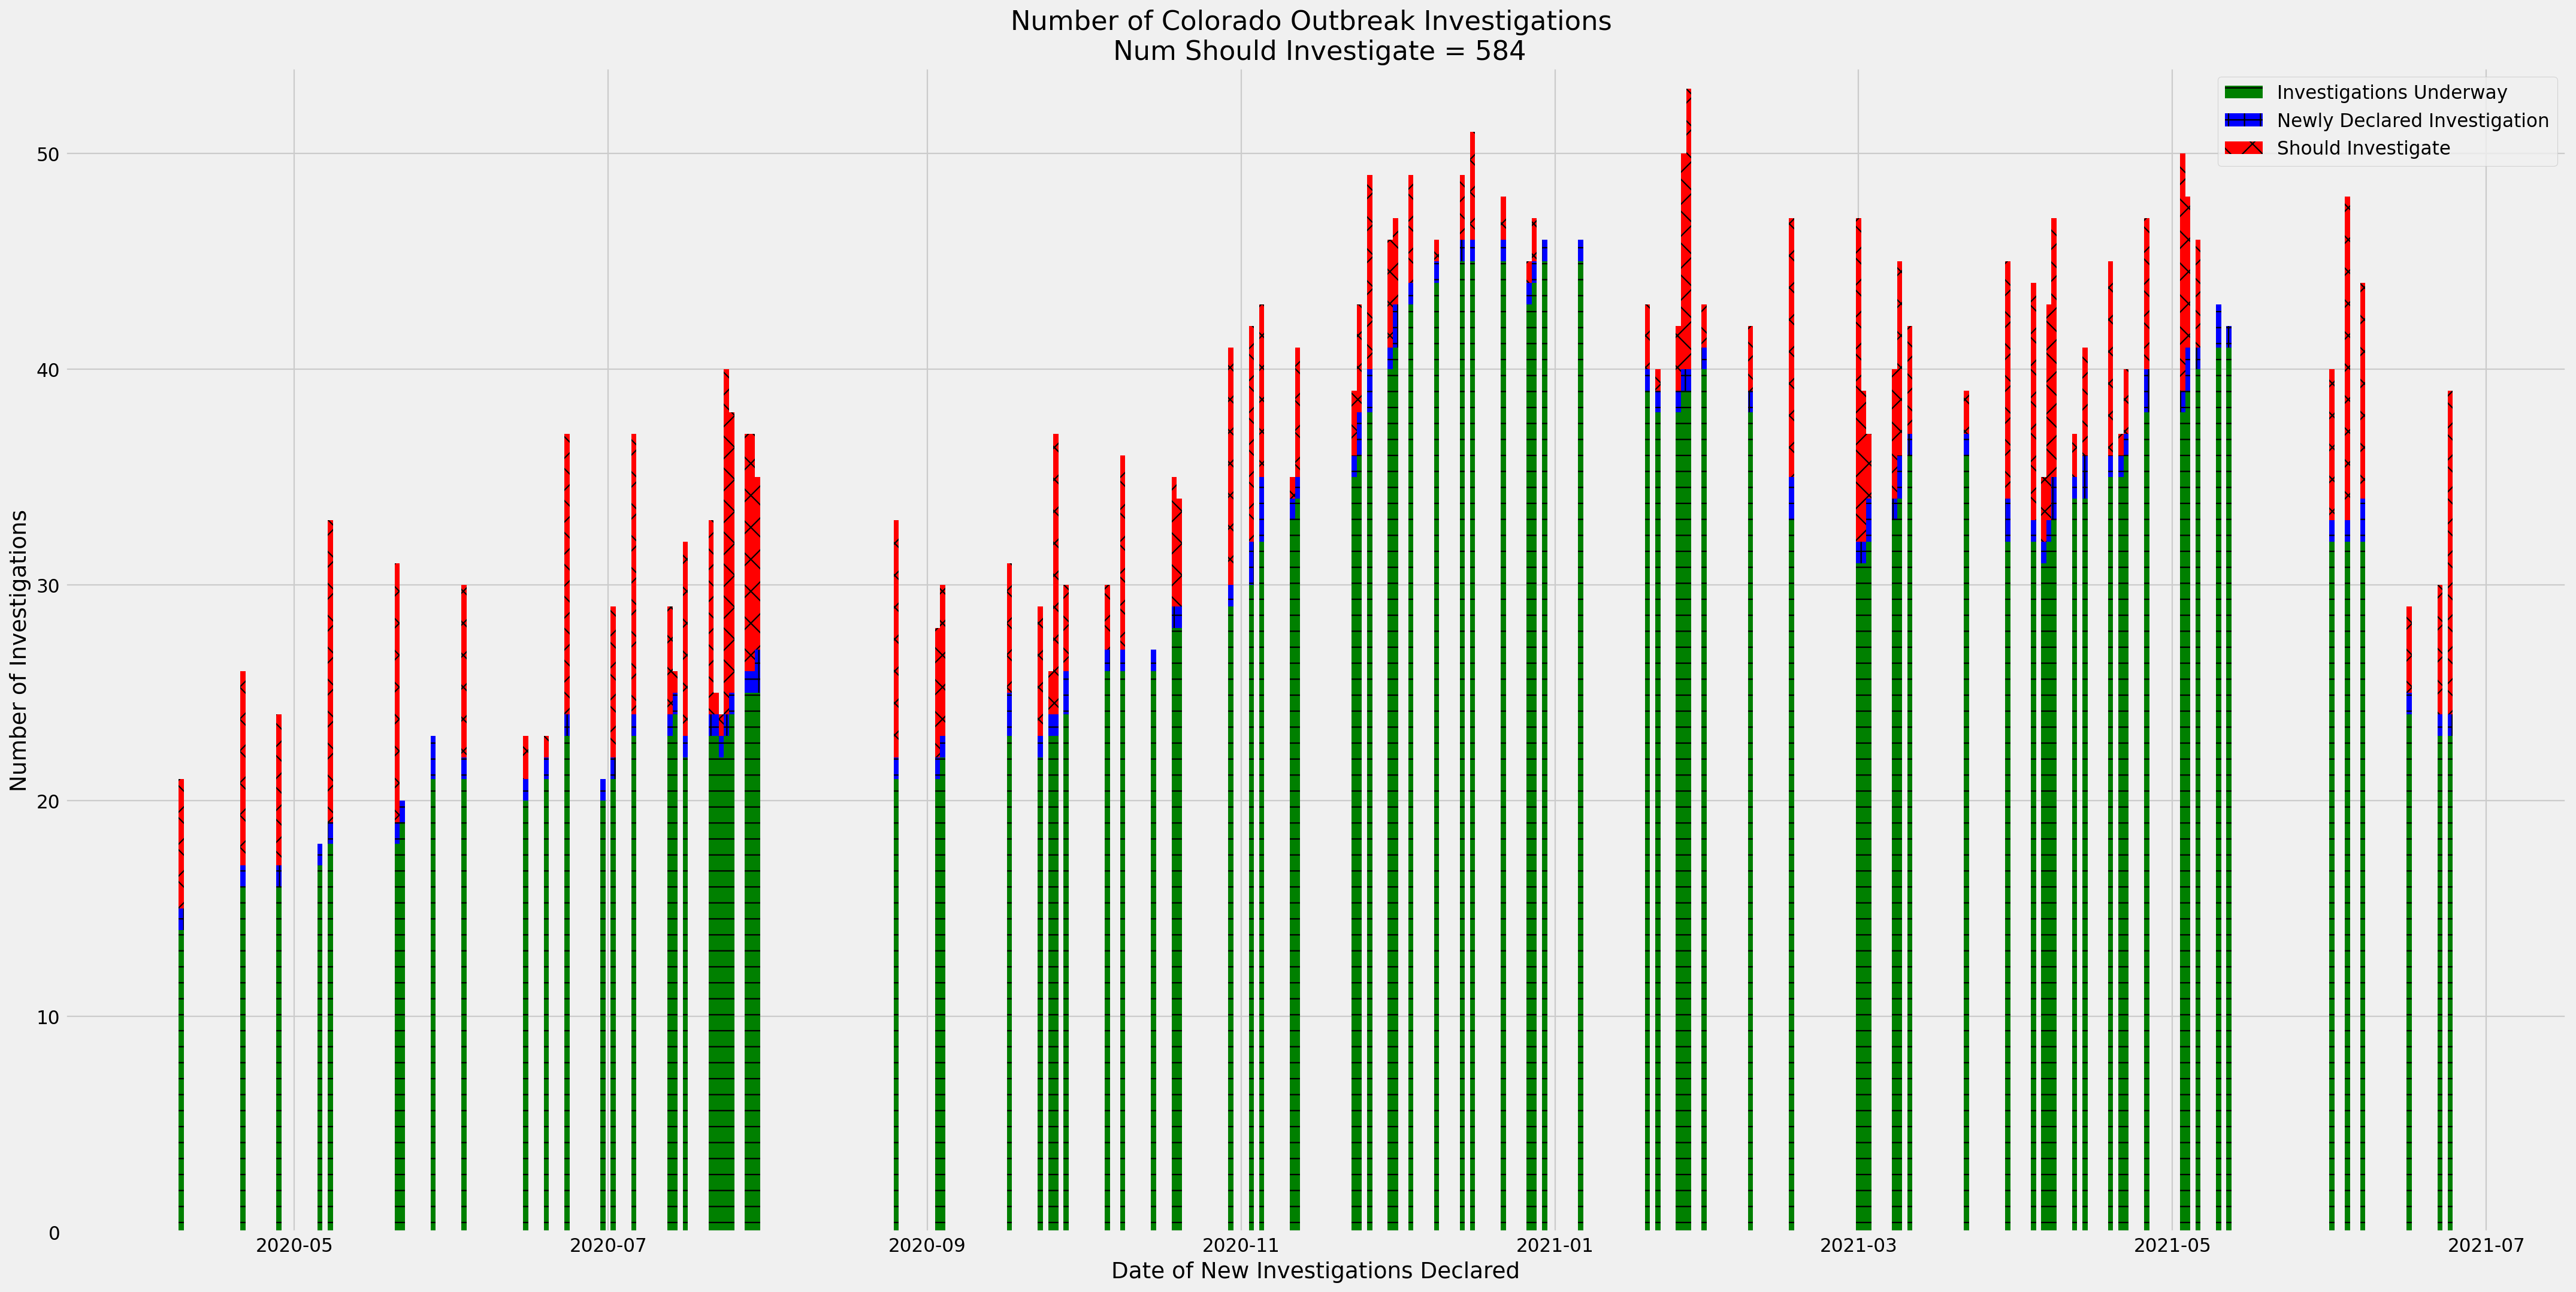

In [73]:
plt.figure(figsize=(30, 15), dpi=160)

patterns = [ "/" , "\\" , "|" , "-" , "+" , "x", "o", "O", ".", "*" ]


plt.bar(xarr, yarr[1], color = "g", hatch="-", width=1.0)
plt.bar(xarr, yarr[2], bottom = yarr[1], color = "b", hatch="+", width=1.0)
plt.bar(xarr, yarr[3], bottom = yarr[2] + yarr[1], color = "r", hatch="x", width=1.0)
plt.ylim(top=54)

plt.legend(["Investigations Underway", "Newly Declared Investigation", "Should Investigate"])
plt.ylabel("Number of Investigations")
plt.xlabel("Date of New Investigations Declared")
plt.title("Number of Colorado Outbreak Investigations \n Num Should Investigate = {}".format(np.sum(yarr[3])))
plt.savefig(os.path.join(FIGURES_FOLDER,"stage1_plot_capacity.png"))

In [74]:
np.shape(yarr), np.shape(xarr)

((4, 95), (95,))

Tally TP, FP, FN, FP

In [75]:
TP, FP, TN, FN = 0,0,0,0

n_changepoints = np.shape(xarr)[0]

#FN = np.sum(yarr[3])
TN = n_changepoints*54 - np.sum(yarr)

P = np.sum(yarr[2])

for i in range(n_changepoints):
    if yarr[3, i] == 0:
        TP += yarr[2, i]
    else:
        FP += yarr[2, i]
FN = P - TP
        
N = TN + FP
print("TP={}, FP={}, TN={}, FN={} out of {}".format(TP, FP, TN, FN, TP+FP+TN+FN))
print("P={}, N={}".format(P, N))
print("TPR={}, TNR={}".format(TP/P, TN/N ))

TP=11, FP=104, TN=778, FN=104 out of 997
P=115, N=882
TPR=0.09565217391304348, TNR=0.8820861678004536


7 days later, how many counties are above the threshold?

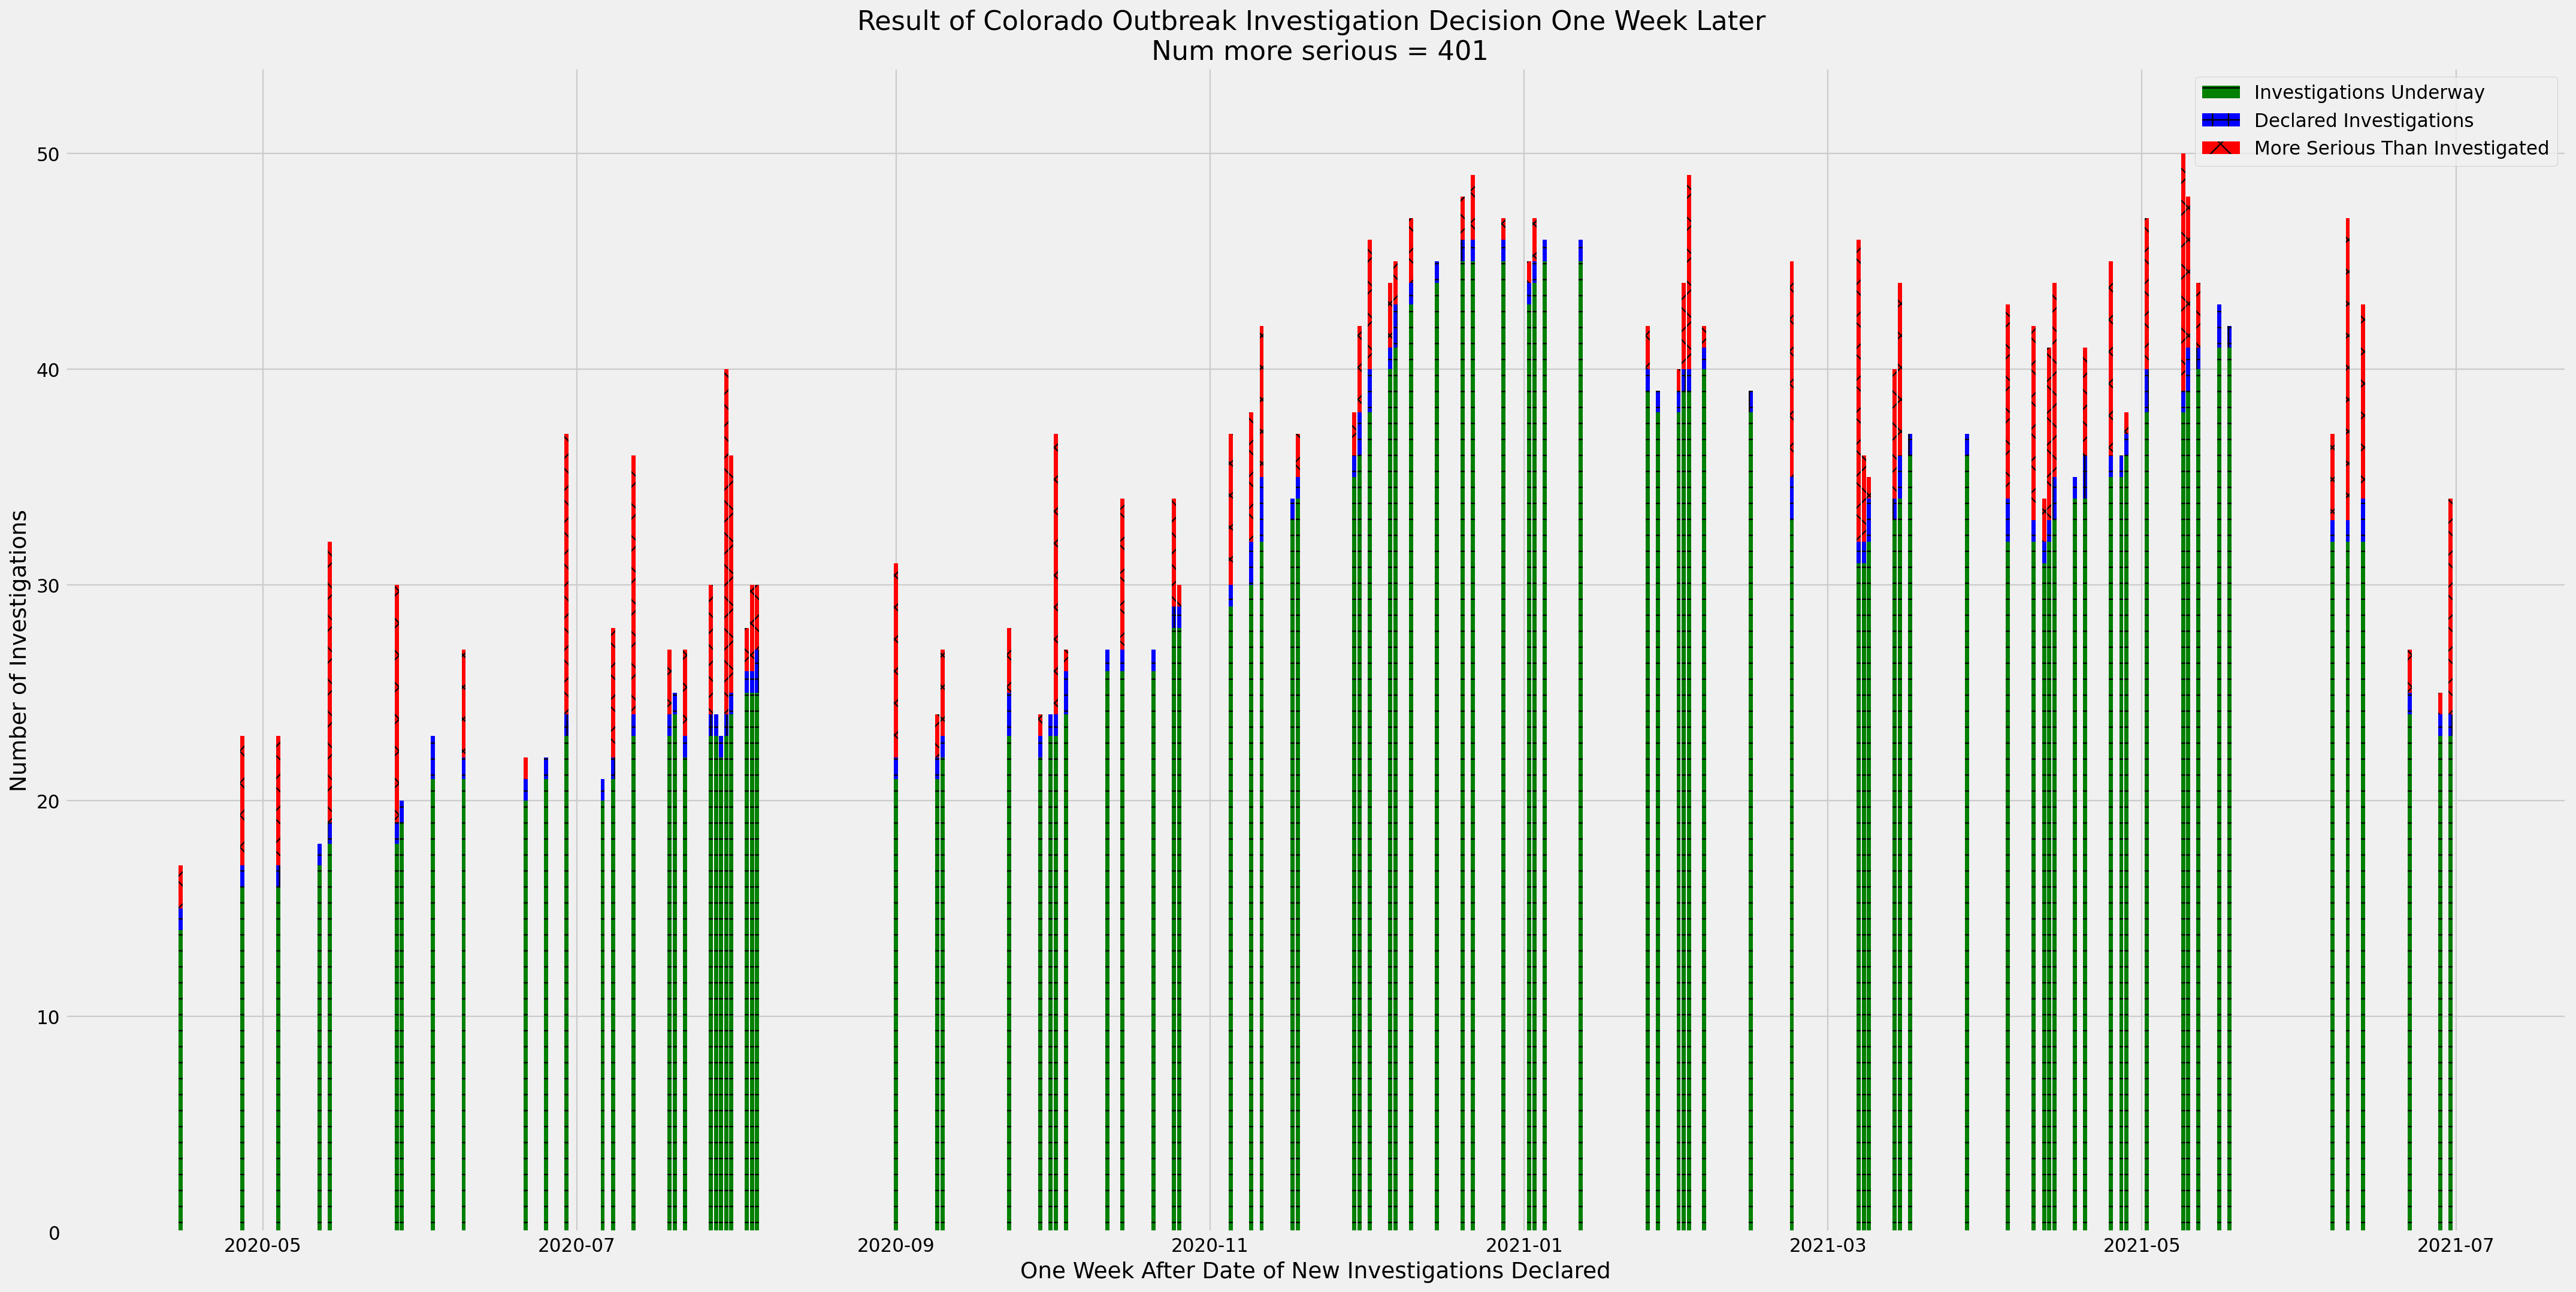

In [76]:
future_red_arr = stage1_df.groupby("date.y")["future_red"].sum().values
xarr_future = (pd.DataFrame(xarr)+pd.DateOffset(days=6)).values.flatten()

plt.figure(figsize=(30, 15), dpi=160)
plt.bar(xarr_future, yarr[1], color = "g", hatch="-")
plt.bar(xarr_future, yarr[2], bottom = yarr[1], color = "b", hatch="+")
plt.bar(xarr_future, future_red_arr, bottom = yarr[2] + yarr[1], color = "r", hatch="x")
plt.ylim(top=54)

plt.legend(["Investigations Underway", "Declared Investigations", "More Serious Than Investigated"])
plt.ylabel("Number of Investigations")
plt.xlabel("One Week After Date of New Investigations Declared")
plt.title("Result of Colorado Outbreak Investigation Decision One Week Later \n Num more serious = {}".format(np.sum(future_red_arr)))
plt.savefig(os.path.join(FIGURES_FOLDER,"stage1_plot_later.png"))

In [77]:
TP, FP, TN, FN = 0,0,0,0

n_changepoints = np.shape(xarr)[0]

#FN = np.sum(yarr[3])
N = n_changepoints*54 - np.sum(yarr)

P = np.sum(yarr[2])

for i in range(n_changepoints):
    if future_red_arr[i] == 0:
        TP += yarr[2, i]
    else:
        FP += yarr[2, i]
FN = P - TP
        
TN = N - FP
print("TP={}, FP={}, TN={}, FN={} out of {}".format(TP, FP, TN, FN, TP+FP+TN+FN))
print("P={}, N={}".format(P, N))
print("TPR={}, TNR={}".format(TP/P, TN/N ))
print("Total = {}".format(P+N))

TP=25, FP=90, TN=688, FN=90 out of 893
P=115, N=778
TPR=0.21739130434782608, TNR=0.884318766066838
Total = 893


In [114]:
#future_red_arr
yarr[2,:]

array([[ 1, 10, 11, 16,  2,  5, 16, 14,  7, 13, 12,  1, 14,  7,  0, 11,
        15, 10, 11, 16, 17,  1,  3,  5,  6,  8,  7, 10,  9, 10,  9, 12,
         2,  8, 11,  4, 13,  6,  9,  6,  5,  6, 14,  8, 13,  9,  3,  7,
         6,  4,  8,  5,  3,  6,  9,  7,  8,  8, 11, 14, 12,  4,  1, 11,
        11,  5,  3, 11, 13,  9,  4,  7, 10,  4,  5, 13,  6,  2, 11,  6,
         3, 12,  9,  3,  1,  3,  5,  8,  9, 10,  3,  7, 21, 19,  9],
       [14, 16, 16, 17, 18, 18, 19, 21, 21, 20, 21, 23, 20, 21, 23, 23,
        24, 22, 23, 23, 22, 23, 24, 25, 25, 25, 21, 21, 22, 23, 22, 23,
        23, 24, 26, 26, 26, 28, 28, 29, 30, 32, 33, 34, 35, 36, 38, 40,
        41, 43, 44, 45, 45, 45, 43, 44, 45, 45, 39, 38, 38, 39, 39, 40,
        38, 33, 31, 31, 32, 33, 34, 36, 36, 32, 32, 31, 32, 33, 34, 34,
        35, 35, 36, 38, 38, 39, 40, 41, 41, 32, 32, 32, 24, 23, 23],
       [ 1,  1,  1,  1,  1,  1,  1,  2,  1,  1,  1,  1,  1,  1,  1,  1,
         1,  1,  1,  1,  1,  1,  1,  1,  1,  2,  1,  1,  1,  2,  1,  1

### Stage 2: We choose to use highest threshold instead

In [78]:
r_thresh_list_stage2 = stage1_df[stage1_df["true_colour"]!=1].groupby("date.y")["r.grf.y"].max()[unique_changepoints]
r_caps_list_stage2 = changepoints_list.groupby("date.y")["r.grf.y"].count()[unique_changepoints]


cp_df_2 = pd.DataFrame({"date.y":unique_changepoints, "r.thresh.y":r_thresh_list_stage2.values, "capacity": r_caps_list_stage2.values})
cp_df_2

,date.y,r.thresh.y,capacity
0,2020-04-09,0.088567,1
1,2020-04-21,0.142646,1
2,2020-04-28,0.185979,1
3,2020-05-06,0.162686,1
4,2020-05-08,0.113529,1
...,...,...,...
90,2021-06-04,0.072849,1
91,2021-06-07,0.067574,2
92,2021-06-16,0.063510,1
93,2021-06-22,0.030806,1


In [79]:
cp_df_2["capacity"].unique()

array([1, 2, 3], dtype=int64)

In [80]:
outbreak_df

,date.y,fips,colour
1242,2020-04-09,8001,1
1243,2020-04-09,8003,0
1244,2020-04-09,8005,1
1245,2020-04-09,8007,0
1246,2020-04-09,8009,0
...,...,...,...
25105,2021-06-24,8117,0
25106,2021-06-24,8119,1
25107,2021-06-24,8121,0
25108,2021-06-24,8123,1


In [81]:
# Join with display_df to get the 4 classes
stage2_df = pd.merge(left=all_backtest_df,right=outbreak_df, how="inner", on=["date.y","fips"])
stage2_df = pd.merge(left=stage2_df,right=cp_df_2, how="left", on=["date.y"])
stage2_cols = ["date.y", "fips", "county", "r.grf.x","r.grf.y","r.gt.z","r.grf.y_RANK","r.gt.z_RANK", "r.thresh.y","colour", "log_rolled_cases.y" ]
stage2_df = stage2_df[stage2_cols]
# Get the true colours 
# How many under investigation already? (Black) 1
# How many changepoints (Started Investigation) 2
# How many that ought to have been investigated given consistent decision (False White) 3
# How many that are OK (True White) 0

d, thresh, cap = cp_df_2.values[0]
stage2_cp_acc = pd.DataFrame()

# Choose from eligible counties: Not green nor changepoint
# tail(cap) chooses the top 1 or 2 or ... (if cap == 1 ...)
# we edit this part
for d, thresh, cap in cp_df_2.values[:]:
    stage2_cp = stage1_df[stage1_df["date.y"]==d]
    stage2_cp = stage2_cp[(stage2_cp["colour"]!=1) | (stage2_cp["cp"]==1)]
    stage2_cp = stage2_cp[stage2_cp["log_rolled_cases.y"] >= np.log(10)]
    stage2_cp = stage2_cp.sort_values(['r.grf.y']).head(len(stage2_cp) - CHOICE_N + 1 ).tail(cap)

    stage2_cp_acc = pd.concat([stage2_cp_acc, stage2_cp])


stage2_cp_acc["cp"] = 1
stage2_cp_acc = stage2_cp_acc[["date.y","fips","cp"]]
# get colour = 2
# Don't merge, loc and set cp
stage2_df = pd.merge(left=stage2_df, right=stage2_cp_acc, how="left", on=["date.y","fips"])
# replace NaN with 0 on "cp"
stage2_df["cp"] = stage2_df["cp"].fillna(0)
stage2_df["cp"] = stage2_df["cp"].astype(np.int64)

stage2_df["true_colour"] = stage2_df["colour"]

mask2_2 = (stage2_df["cp"] == 1)
stage2_df.loc[mask2_2,"true_colour"] = 2

mask3_2 = (stage2_df["colour"] == 0) & (stage2_df["r.grf.y"] > stage2_df["r.thresh.y"])
stage2_df.loc[mask3_2,"true_colour"] = 3

# Not under investigation in future but >= threshold
future_mask_2 = (stage2_df["r.gt.z"] > stage2_df["r.thresh.y"]) & (stage2_df["true_colour"] == 0)

stage2_df["future_red"] = future_mask_2.copy().astype(np.int64)

stage2_df

,date.y,fips,county,r.grf.x,r.grf.y,r.gt.z,r.grf.y_RANK,r.gt.z_RANK,r.thresh.y,colour,log_rolled_cases.y,cp,true_colour,future_red
0,2020-04-09,8001,Adams,0.190322,0.071774,0.079653,20.0,22.0,0.088567,1,5.999557,0,1,0
1,2020-04-21,8001,Adams,0.061408,0.017410,0.037692,29.0,34.0,0.142646,1,6.728629,0,1,0
2,2020-04-28,8001,Adams,0.017410,0.019223,0.019314,31.0,32.0,0.185979,1,6.941190,0,1,0
3,2020-05-06,8001,Adams,0.024113,0.012520,0.018611,25.0,32.0,0.162686,1,7.084017,0,1,0
4,2020-05-08,8001,Adams,0.030420,0.026854,0.011617,32.0,32.0,0.113529,1,7.134094,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4347,2021-06-04,8125,Yuma,-0.013355,0.011323,0.005268,42.0,48.0,0.072849,1,3.725693,0,1,0
4348,2021-06-07,8125,Yuma,-0.038475,0.015689,-0.016421,50.0,36.0,0.067574,1,3.772761,0,1,0
4349,2021-06-16,8125,Yuma,-0.014025,-0.027019,-0.048216,26.0,15.0,0.063510,1,3.663562,0,1,0
4350,2021-06-22,8125,Yuma,-0.017605,-0.026606,-0.117736,23.0,4.0,0.030806,1,3.384390,0,1,0


In [111]:
#stage1_df[stage1_df["county"]=="Alamosa"]
stage2_df[stage2_df["county"]=="Alamosa"]

,date.y,fips,county,r.grf.x,r.grf.y,r.gt.z,r.grf.y_RANK,r.gt.z_RANK,r.thresh.y,colour,log_rolled_cases.y,cp,true_colour,future_red
95,2020-04-21,8003,Alamosa,0.013911,0.030436,-0.043152,33.0,11.0,0.142646,0,1.945910,0,0,0
96,2020-04-28,8003,Alamosa,0.030436,0.003763,-0.024011,24.0,11.0,0.185979,0,1.791759,0,0,0
97,2020-05-06,8003,Alamosa,0.007056,0.162686,0.102925,40.0,39.0,0.162686,1,2.140066,0,1,0
98,2020-05-08,8003,Alamosa,-0.097532,0.161362,0.074210,40.0,40.0,0.113529,1,2.674149,0,1,0
99,2020-05-21,8003,Alamosa,0.098101,0.080105,0.026516,38.0,30.0,0.132704,1,3.548180,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
184,2021-06-04,8003,Alamosa,0.007935,-0.046312,-0.060613,14.0,8.0,0.072849,1,5.023881,0,1,0
185,2021-06-07,8003,Alamosa,-0.035461,-0.058610,-0.069717,17.0,8.0,0.067574,1,4.836282,0,1,0
186,2021-06-16,8003,Alamosa,-0.055129,-0.064224,-0.110529,4.0,3.0,0.063510,1,4.215824,0,1,0
187,2021-06-22,8003,Alamosa,-0.064479,-0.072572,-0.057697,5.0,13.0,0.030806,1,3.533687,0,1,0


In [83]:
test_future_red_2 = np.zeros(stage2_df.shape[0])
for i,d in enumerate(cp_df_2["date.y"]):
    dmask = stage2_df["date.y"] == d
    thresh = cp_df_2.loc[i,"r.thresh.y"]
    cp_indx = (stage2_df["r.grf.y"] == thresh)
    more_serious = (stage2_df["r.gt.z"] > stage2_df[cp_indx]["r.gt.z"].min()) & (stage2_df["true_colour"]==0)
    test_future_red_2[dmask] = more_serious[dmask]


In [84]:
np.sum((test_future_red_2))

295.0

In [85]:
tc_counts_2 = stage2_df.groupby("date.y")["true_colour"].value_counts().unstack(fill_value=0).stack()
tc_counts_df_2 = tc_counts_2.reset_index(level=[0,1])
tc_counts_df_2 = tc_counts_df_2.rename(columns={0:"count"})
yarr_2 = tc_counts_2.values.reshape(len(tc_counts_2)//3,3).T
xarr_2 = unique_changepoints

tc_counts_df_2

,date.y,true_colour,count
0,2020-04-09,0,6
1,2020-04-09,1,15
2,2020-04-09,2,1
3,2020-04-21,0,18
4,2020-04-21,1,17
...,...,...,...
280,2021-06-22,1,24
281,2021-06-22,2,1
282,2021-06-24,0,23
283,2021-06-24,1,24


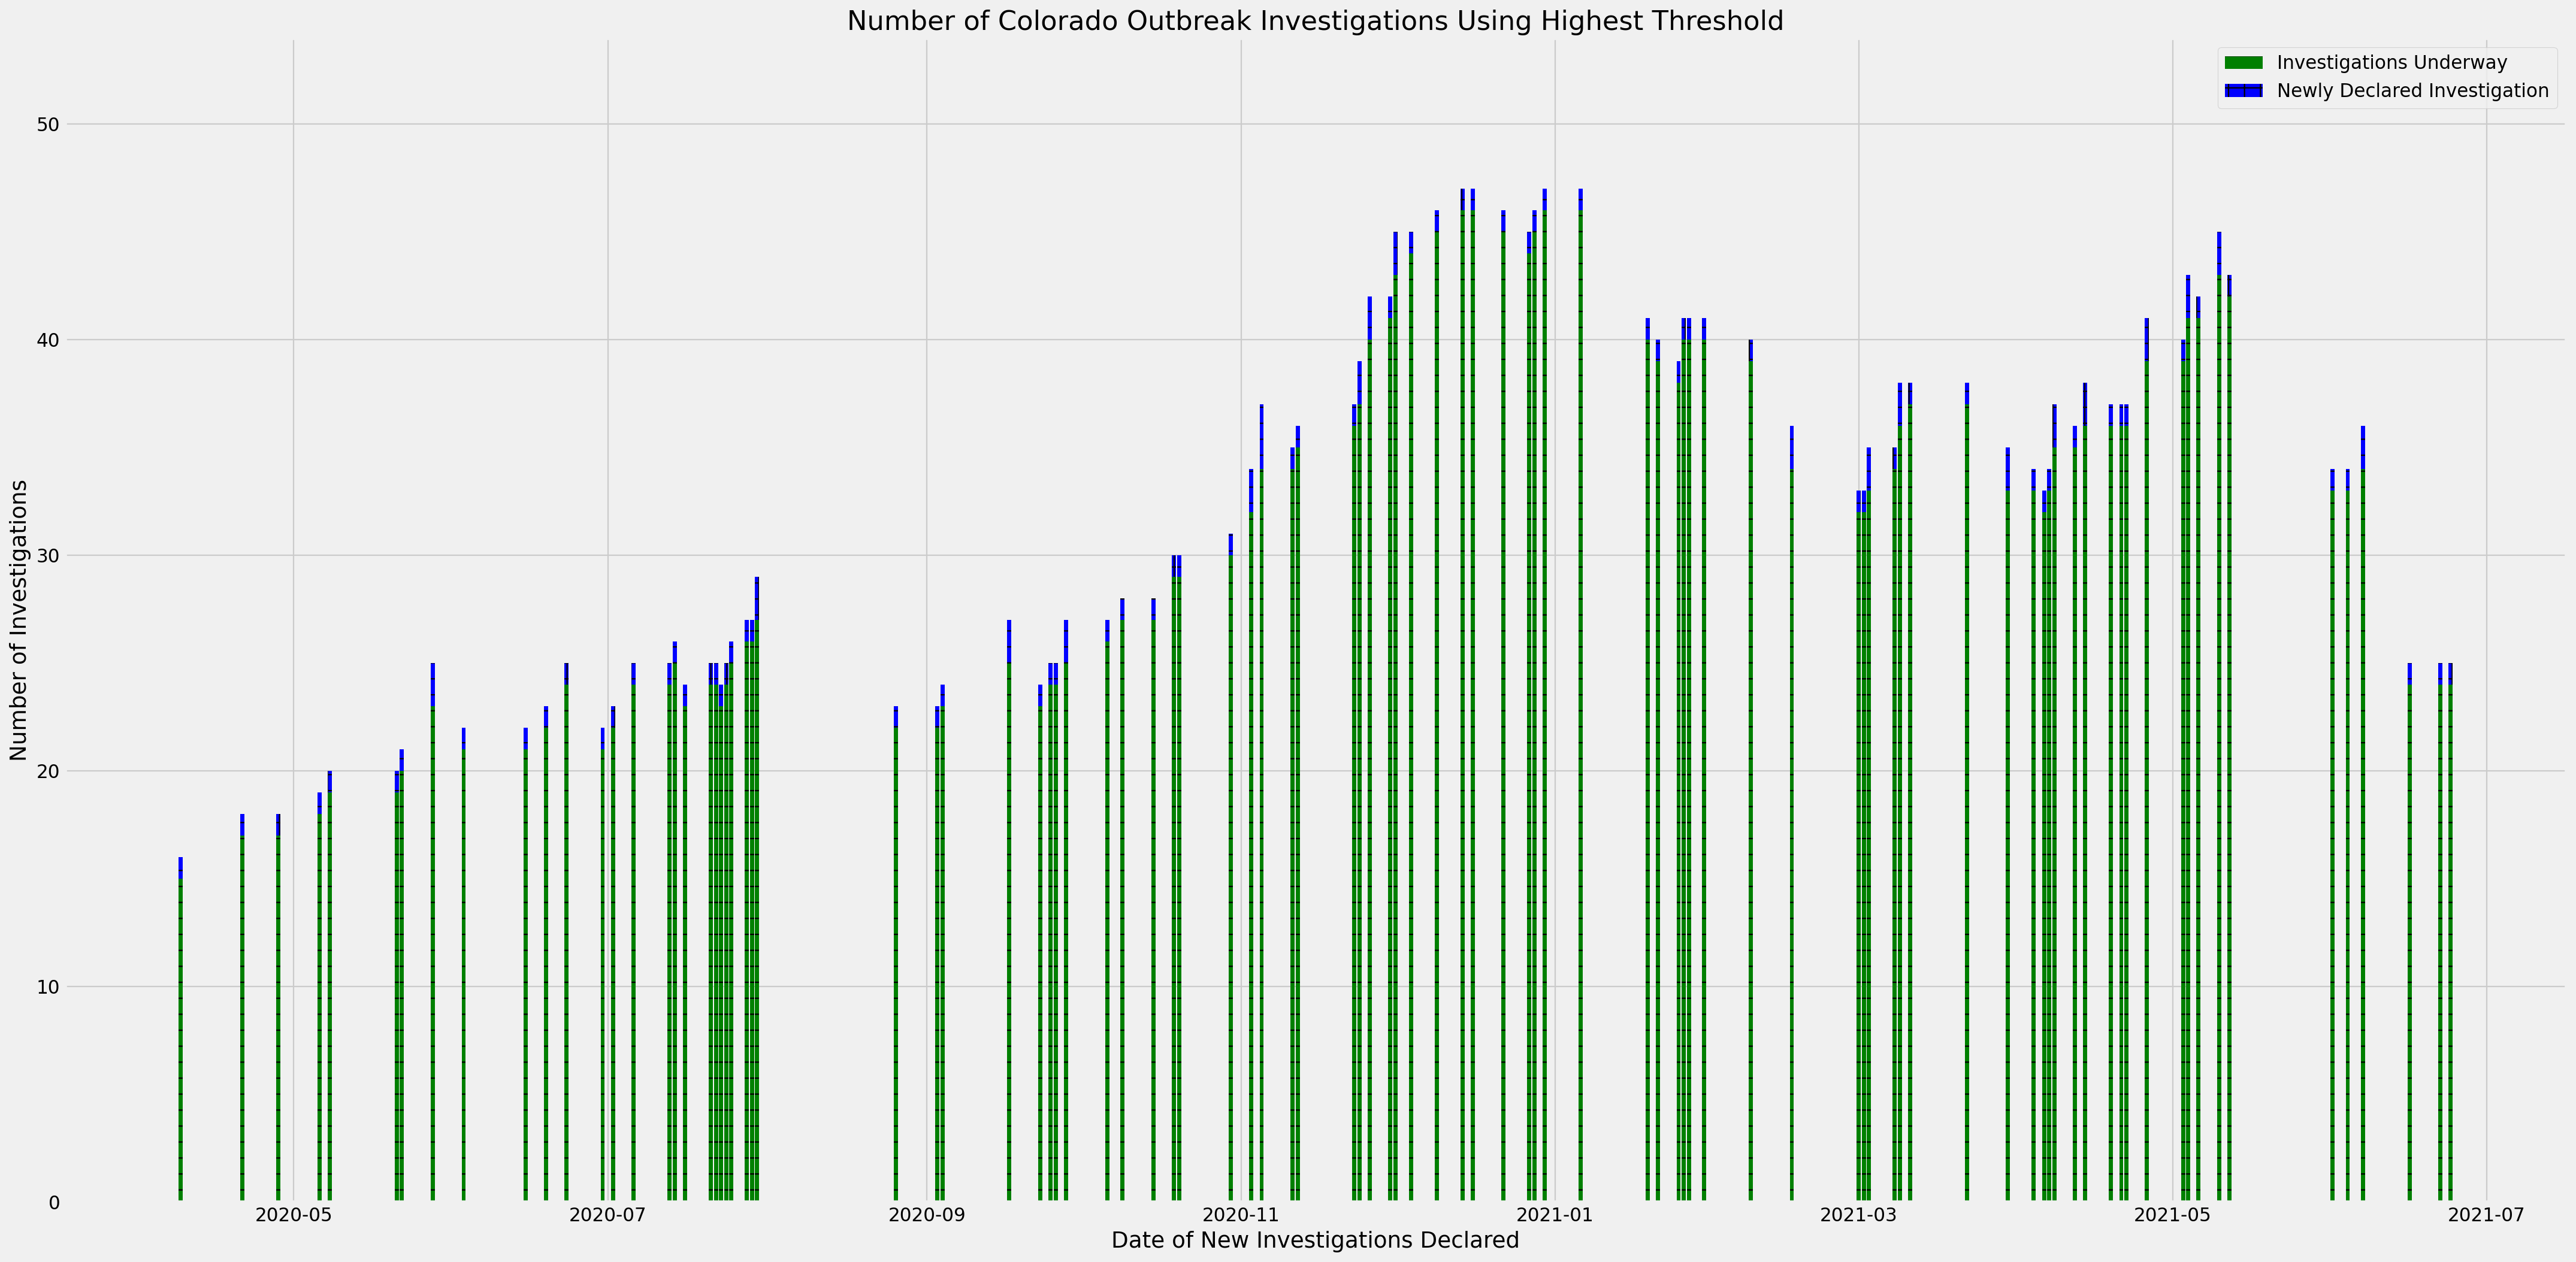

In [86]:
plt.figure(figsize=(30, 15), dpi=160)
plt.bar(xarr_2, yarr_2[1], color = "g", hatch="-")
plt.bar(xarr_2, yarr_2[2], bottom = yarr_2[1], color = "b", hatch="+")
#plt.bar(xarr_2, yarr_2[3], bottom = yarr_2[2] + yarr_2[1], color = "r")
plt.ylim(top=54)

plt.legend(["Investigations Underway", "Newly Declared Investigation"])
plt.ylabel("Number of Investigations")
plt.xlabel("Date of New Investigations Declared")
plt.title("Number of Colorado Outbreak Investigations Using Highest Threshold")
plt.savefig(os.path.join(FIGURES_FOLDER,"stage2_plot_capacity.png"))

### Plot Stage 1 and Stage 2 One Week Later Side by Side

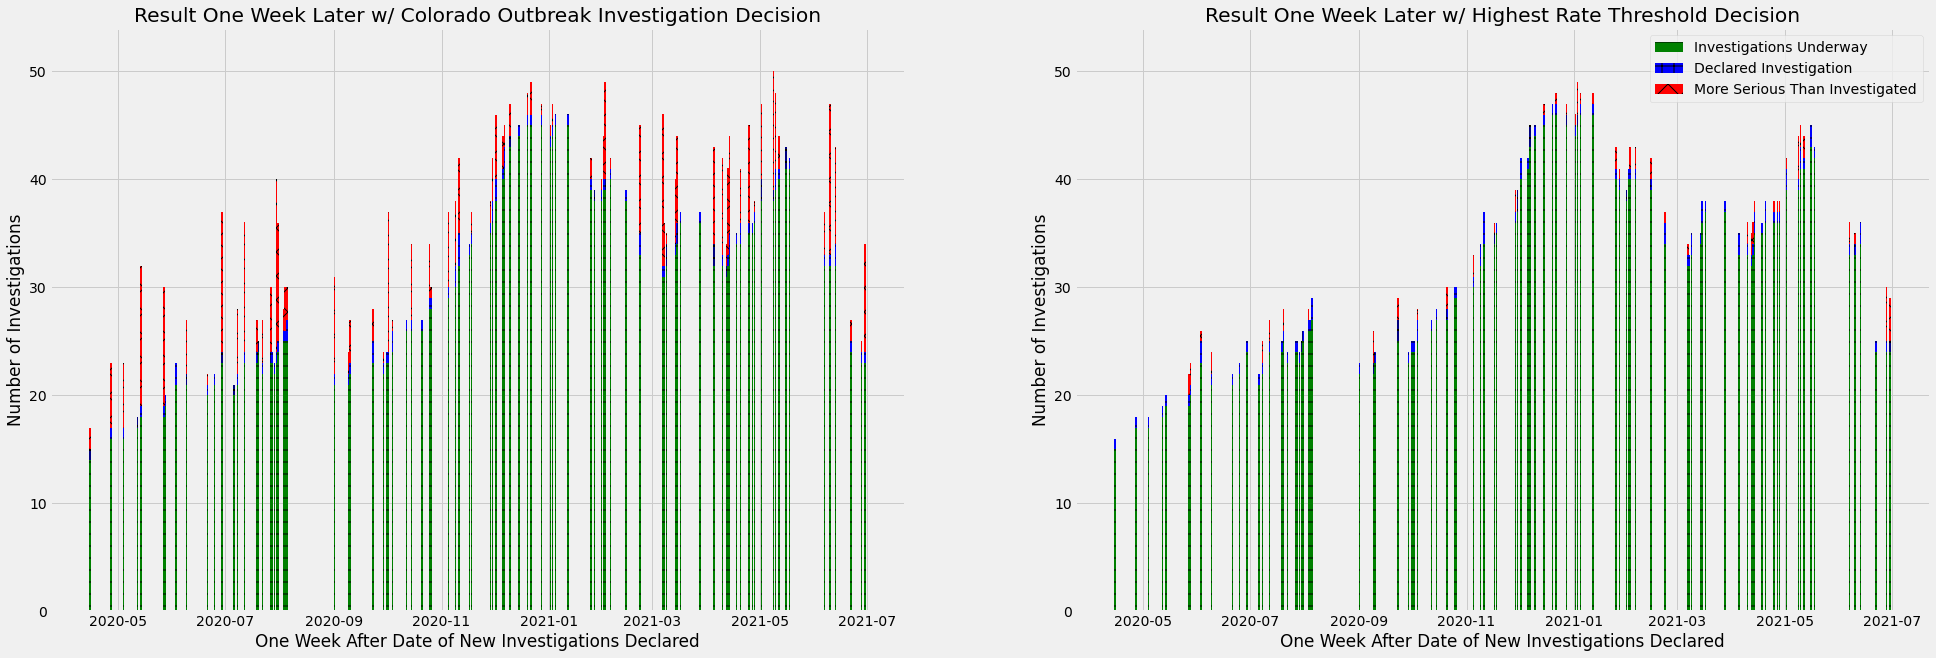

In [87]:
future_red_arr = stage1_df.groupby("date.y")["future_red"].sum().values
xarr_future = (pd.DataFrame(xarr)+pd.DateOffset(days=6)).values.flatten()

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(30, 10))

axes[0].bar(xarr_future, yarr[1], color = "g", hatch="-")
axes[0].bar(xarr_future, yarr[2], bottom = yarr[1], color = "b", hatch="+")
axes[0].bar(xarr_future, future_red_arr, bottom = yarr[2] + yarr[1], color = "r", hatch="x")
axes[0].set_ylim(top=54)

#axes[0].legend(["Investigations Underway", "Declared Investigations", "More Serious Than Investigated"])
axes[0].set_ylabel("Number of Investigations")
axes[0].set_xlabel("One Week After Date of New Investigations Declared")
axes[0].set_title("Result One Week Later w/ Colorado Outbreak Investigation Decision".format(np.sum(future_red_arr)))
#plt.savefig(os.path.join(FIGURES_FOLDER,"stage1_plot_later.png"))

##############
future_red_arr_2 = stage2_df.groupby("date.y")["future_red"].sum().values
xarr_2_future = (pd.DataFrame(xarr_2)+pd.DateOffset(days=6)).values.flatten()

axes[1].bar(xarr_2_future, yarr_2[1], color = "g", hatch="-")
axes[1].bar(xarr_2_future, yarr_2[2], bottom = yarr_2[1], color = "b", hatch="+")
axes[1].bar(xarr_2_future, future_red_arr_2, bottom = yarr_2[2] + yarr_2[1], color = "r", hatch="x")
axes[1].set_ylim(top=54)

plt.legend(["Investigations Underway", "Declared Investigation", "More Serious Than Investigated"])
axes[1].set_ylabel("Number of Investigations")
axes[1].set_xlabel("One Week After Date of New Investigations Declared")
axes[1].set_title("Result One Week Later w/ Highest Rate Threshold Decision".format(np.sum(future_red_arr_2)))
#plt.title("Results of Investigation One Week Later")
plt.savefig(os.path.join(FIGURES_FOLDER,"combined_plot_later.png"))

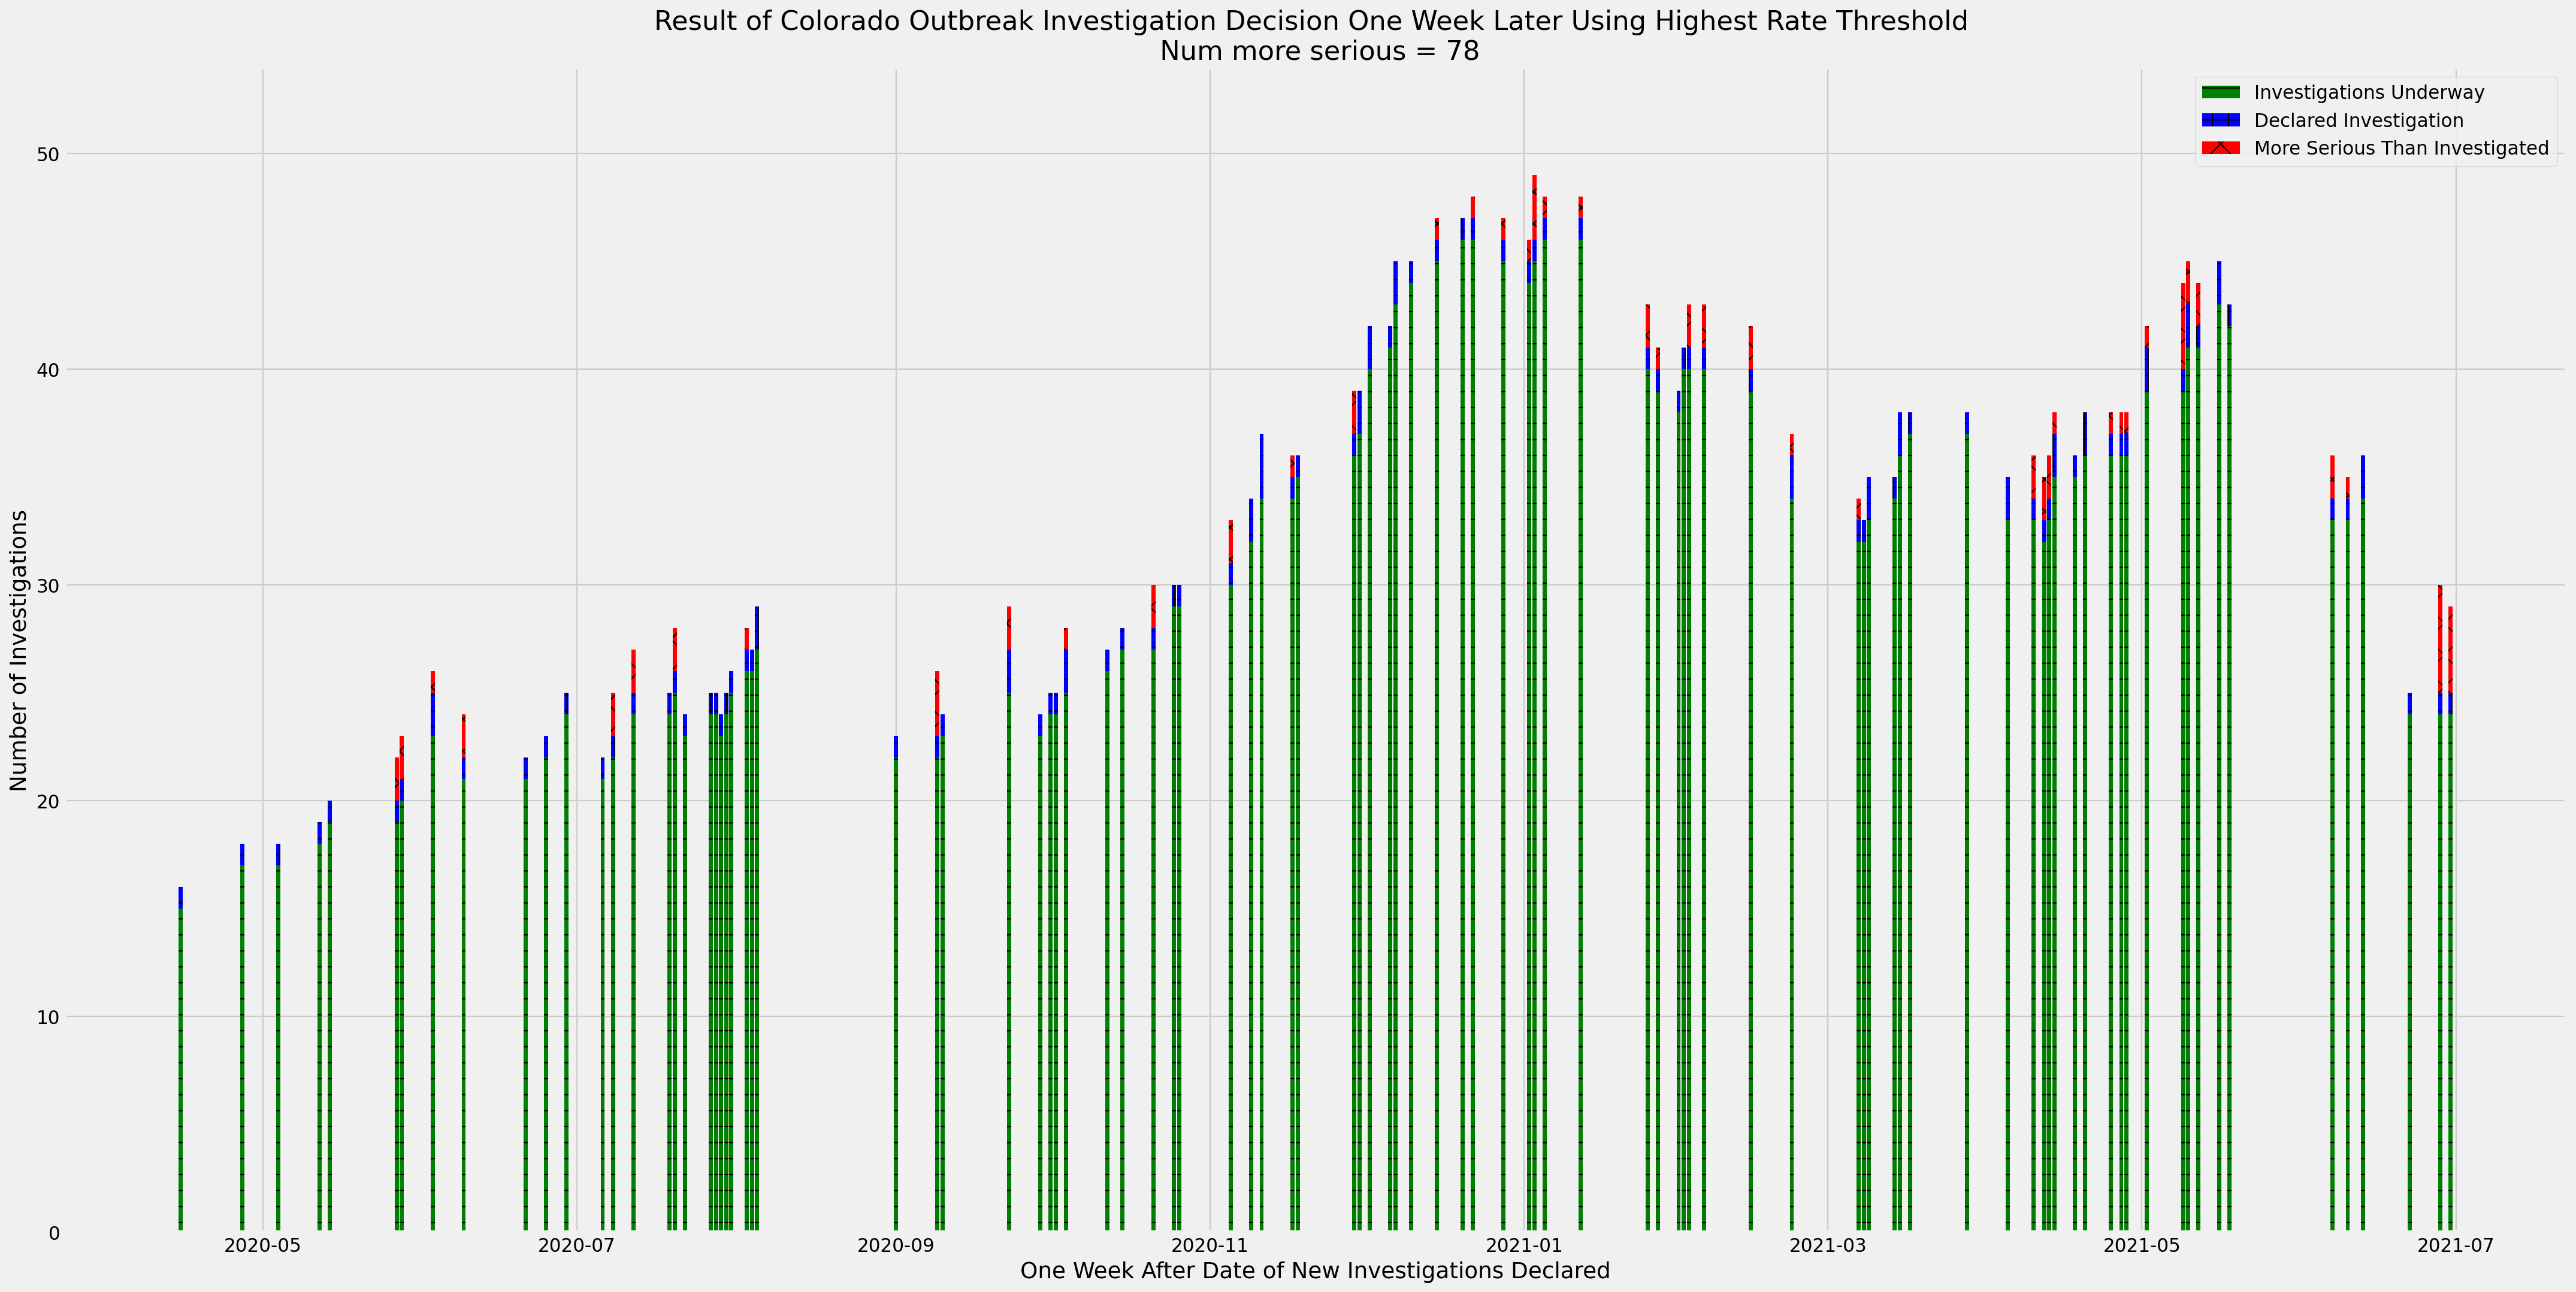

In [88]:
future_red_arr_2 = stage2_df.groupby("date.y")["future_red"].sum().values
xarr_2_future = (pd.DataFrame(xarr_2)+pd.DateOffset(days=6)).values.flatten()

plt.figure(figsize=(30, 15), dpi=160)
plt.bar(xarr_2_future, yarr_2[1], color = "g", hatch="-")
plt.bar(xarr_2_future, yarr_2[2], bottom = yarr_2[1], color = "b", hatch="+")
plt.bar(xarr_2_future, future_red_arr_2, bottom = yarr_2[2] + yarr_2[1], color = "r", hatch="x")
plt.ylim(top=54)

plt.legend(["Investigations Underway", "Declared Investigation", "More Serious Than Investigated"])
plt.ylabel("Number of Investigations")
plt.xlabel("One Week After Date of New Investigations Declared")
plt.title("Result of Colorado Outbreak Investigation Decision One Week Later Using Highest Rate Threshold \n Num more serious = {}".format(np.sum(future_red_arr_2)))
plt.savefig(os.path.join(FIGURES_FOLDER,"stage2_plot_later.png"))

In [89]:
TP, FP, TN, FN = 0,0,0,0

n_changepoints = np.shape(xarr_2)[0]

#FN = np.sum(yarr[3])
N = n_changepoints*54 - np.sum(yarr_2)

P = np.sum(yarr_2[2])

for i in range(n_changepoints):
    if future_red_arr_2[i] == 0:
        TP += yarr_2[2, i]
    else:
        FP += yarr_2[2, i]
FN = P - TP
        
TN = N - FP
with open(os.path.join(TLGRF_N_FOLDER,"confusion_TLGRF_{}.txt".format(CHOICE_N)), "w") as tp:
    l0 = ("TLGRF Top {}\n".format(CHOICE_N))
    l1 = ("TP={}, FP={}, TN={}, FN={} out of {}\n".format(TP, FP, TN, FN, TP+FP+TN+FN))
    l2 = ("P={}, N={} \n".format(P, N))
    l3 = ("TPR={}, TNR={} \n".format(TP/P, TN/N ))
    l4 = ("Total = {} \n".format(P+N))
    tp.write(l0 + l1 + l2 + l3 + l4)

### Plot Stage 1 and Stage 2 Together

In [90]:
TP, FP, TN, FN = 0,0,0,0

n_changepoints = np.shape(xarr)[0]

#FN = np.sum(yarr[3])
N = n_changepoints*54 - np.sum(yarr)

P = np.sum(yarr[2])

for i in range(n_changepoints):
    if future_red_arr[i] == 0:
        TP += yarr[2, i]
    else:
        FP += yarr[2, i]
FN = P - TP
        
TN = N - FP
with open(os.path.join(OUTPUT_FOLDER,"confusion_CDPHE.txt"), "w") as tp:
    l0 = ("CDPHE {}\n".format(CHOICE_N))
    l1 = ("TP={}, FP={}, TN={}, FN={} out of {}\n".format(TP, FP, TN, FN, TP+FP+TN+FN))
    l2 = ("P={}, N={} \n".format(P, N))
    l3 = ("TPR={}, TNR={} \n".format(TP/P, TN/N ))
    l4 = ("Total = {} \n".format(P+N))
    tp.write(l0 + l1 + l2 + l3 + l4)
################################################
TP, FP, TN, FN = 0,0,0,0

n_changepoints = np.shape(xarr_2)[0]

#FN = np.sum(yarr[3])
N = n_changepoints*54 - np.sum(yarr_2)

P = np.sum(yarr_2[2])

for i in range(n_changepoints):
    if future_red_arr_2[i] == 0:
        TP += yarr_2[2, i]
    else:
        FP += yarr_2[2, i]
FN = P - TP
        
TN = N - FP
with open(os.path.join(TLGRF_N_FOLDER,"confusion_TLGRF_{}.txt".format(CHOICE_N)), "w") as tp:
    l0 = ("TLGRF Top {}\n".format(CHOICE_N))
    l1 = ("TP={}, FP={}, TN={}, FN={} out of {}\n".format(TP, FP, TN, FN, TP+FP+TN+FN))
    l2 = ("P={}, N={} \n".format(P, N))
    l3 = ("TPR={}, TNR={} \n".format(TP/P, TN/N ))
    l4 = ("Total = {} \n".format(P+N))
    tp.write(l0 + l1 + l2 + l3 + l4)

In [105]:
yarr

array([[ 1, 10, 11, 16,  2,  5, 16, 14,  7, 13, 12,  1, 14,  7,  0, 11,
        15, 10, 11, 16, 17,  1,  3,  5,  6,  8,  7, 10,  9, 10,  9, 12,
         2,  8, 11,  4, 13,  6,  9,  6,  5,  6, 14,  8, 13,  9,  3,  7,
         6,  4,  8,  5,  3,  6,  9,  7,  8,  8, 11, 14, 12,  4,  1, 11,
        11,  5,  3, 11, 13,  9,  4,  7, 10,  4,  5, 13,  6,  2, 11,  6,
         3, 12,  9,  3,  1,  3,  5,  8,  9, 10,  3,  7, 21, 19,  9],
       [14, 16, 16, 17, 18, 18, 19, 21, 21, 20, 21, 23, 20, 21, 23, 23,
        24, 22, 23, 23, 22, 23, 24, 25, 25, 25, 21, 21, 22, 23, 22, 23,
        23, 24, 26, 26, 26, 28, 28, 29, 30, 32, 33, 34, 35, 36, 38, 40,
        41, 43, 44, 45, 45, 45, 43, 44, 45, 45, 39, 38, 38, 39, 39, 40,
        38, 33, 31, 31, 32, 33, 34, 36, 36, 32, 32, 31, 32, 33, 34, 34,
        35, 35, 36, 38, 38, 39, 40, 41, 41, 32, 32, 32, 24, 23, 23],
       [ 1,  1,  1,  1,  1,  1,  1,  2,  1,  1,  1,  1,  1,  1,  1,  1,
         1,  1,  1,  1,  1,  1,  1,  1,  1,  2,  1,  1,  1,  2,  1,  1

### Case Study: Match and Compare our choice with theirs

In [91]:
county_features_df = pd.read_csv(os.path.join(DATA_FOLDER, "county_features.csv"))
county_features_df

,LAT,LON,ST,STATE,ST_ABBR,COUNTY,FIPS,LOCATION,AREA_SQMI,E_TOTPOP,M_TOTPOP,E_HU,M_HU,E_HH,M_HH,E_POV,M_POV,E_UNEMP,M_UNEMP,E_PCI,M_PCI,E_NOHSDP,M_NOHSDP,E_AGE65,M_AGE65,E_AGE17,M_AGE17,E_DISABL,M_DISABL,E_SNGPNT,M_SNGPNT,E_MINRTY,M_MINRTY,E_LIMENG,M_LIMENG,E_MUNIT,M_MUNIT,E_MOBILE,M_MOBILE,E_CROWD,M_CROWD,E_NOVEH,M_NOVEH,E_GROUPQ,M_GROUPQ,EP_POV,MP_POV,EP_UNEMP,MP_UNEMP,EP_PCI,MP_PCI,EP_NOHSDP,MP_NOHSDP,EP_AGE65,MP_AGE65,EP_AGE17,MP_AGE17,EP_DISABL,MP_DISABL,EP_SNGPNT,MP_SNGPNT,EP_MINRTY,MP_MINRTY,EP_LIMENG,MP_LIMENG,EP_MUNIT,MP_MUNIT,EP_MOBILE,MP_MOBILE,EP_CROWD,MP_CROWD,EP_NOVEH,MP_NOVEH,EP_GROUPQ,MP_GROUPQ,EPL_POV,EPL_UNEMP,EPL_PCI,EPL_NOHSDP,SPL_THEME1,RPL_THEME1,EPL_AGE65,EPL_AGE17,EPL_DISABL,EPL_SNGPNT,SPL_THEME2,RPL_THEME2,EPL_MINRTY,EPL_LIMENG,SPL_THEME3,RPL_THEME3,EPL_MUNIT,EPL_MOBILE,EPL_CROWD,EPL_NOVEH,EPL_GROUPQ,SPL_THEME4,RPL_THEME4,SPL_THEMES,RPL_THEMES,F_POV,F_UNEMP,F_PCI,F_NOHSDP,F_THEME1,F_AGE65,F_AGE17,F_DISABL,F_SNGPNT,F_THEME2,F_MINRTY,F_LIMENG,F_THEME3,F_MUNIT,F_MOBILE,F_CROWD,F_NOVEH,F_GROUPQ,F_THEME4,F_TOTAL,E_UNINSUR,M_UNINSUR,EP_UNINSUR,MP_UNINSUR,E_DAYPOP
0,32.532237,-86.646440,1.0,ALABAMA,AL,Autauga,1001.0,"Autauga County, Alabama",594.443459,55200.0,0.0,23315.0,71.0,21115.0,383.0,8422.0,1137.0,1065.0,257.0,29372.0,2306.0,4204.0,475.0,8050.0,75.0,13369.0,32.0,10465.0,729.0,1586.0,319.9,13788.0,59.0,426.0,205.9,886.0,308.7,4279.0,469.0,299.0,142.3,1191.0,272.0,546.0,161.0,15.4,2.1,4.2,1.0,29372.0,2306.0,11.3,1.3,14.6,0.1,24.2,0.1,19.3,1.3,7.5,1.5,25.0,0.1,0.8,0.4,3.8,1.3,18.4,2.0,1.4,0.7,5.6,1.3,1.0,0.3,0.5401,0.2745,0.2860,0.4397,1.5403,0.3631,0.1850,0.7529,0.7905,0.3792,2.1076,0.5810,0.6336,0.5113,1.1449,0.5947,0.6017,0.7408,0.2964,0.4846,0.1525,2.2760,0.3741,7.0688,0.4354,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3875.0,508.0,7.1,0.9,37301.0
1,30.659218,-87.746067,1.0,ALABAMA,AL,Baldwin,1003.0,"Baldwin County, Alabama",1589.793007,208107.0,0.0,111945.0,206.0,78622.0,1183.0,21653.0,1765.0,4343.0,620.0,31203.0,716.0,14310.0,1211.0,40665.0,69.0,45677.0,0.0,28863.0,1217.0,4508.0,581.4,35339.0,227.0,1068.0,323.6,20492.0,1203.0,13075.0,831.0,991.0,248.5,2705.0,443.0,3014.0,459.0,10.6,0.9,4.4,0.6,31203.0,716.0,9.7,0.8,19.5,0.1,21.9,0.0,14.0,0.6,5.7,0.7,17.0,0.1,0.5,0.2,18.3,1.1,11.7,0.7,1.3,0.3,3.4,0.6,1.4,0.2,0.2239,0.3121,0.2057,0.3209,1.0626,0.2232,0.6428,0.4323,0.3524,0.1391,1.5666,0.1990,0.5158,0.3582,0.8740,0.4358,0.9713,0.5339,0.2604,0.1328,0.3018,2.2002,0.3359,5.7034,0.2162,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,20864.0,1646.0,10.2,0.8,195677.0
2,31.870253,-85.405104,1.0,ALABAMA,AL,Barbour,1005.0,"Barbour County, Alabama",885.001636,25782.0,0.0,11937.0,123.0,9186.0,280.0,6597.0,661.0,918.0,201.0,18461.0,819.0,4901.0,333.0,4634.0,29.0,5436.0,38.0,5078.0,387.0,1174.0,187.9,13884.0,22.0,398.0,165.2,152.0,79.3,3484.0,239.0,313.0,144.4,849.0,146.0,2900.0,275.0,28.9,2.9,9.5,2.0,18461.0,819.0,27.0,1.8,18.0,0.1,21.1,0.1,22.2,1.7,12.8,2.0,53.9,0.1,1.6,0.7,1.3,0.7,29.2,2.0,3.4,1.6,9.2,1.5,11.2,1.1,0.9631,0.9217,0.9481,0.9701,3.8030,0.9780,0.4893,0.3327,0.9064,0.9468,2.6752,0.9153,0.8965,0.7052,1.6017,0.8558,0.2416,0.9280,0.8198,0.8685,0.9449,3.8028,0.9889,11.8827,0.9959,1.0,1.0,1.0,1.0,4.0,0.0,0.0,1.0,1.0,2.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,2.0,8.0,2558.0,363.0,11.2,1.6,25052.0
3,33.015893,-87.127148,1.0,ALABAMA,AL,Bibb,1007.0,"Bibb County, Alabama",622.461089,22527.0,0.0,9161.0,77.0,6840.0,321.0,2863.0,770.0,658.0,225.0,20199.0,1182.0,2650.0,346.0,3661.0,161.0,4659.0,0.0,3412.0,425.0,407.0,160.6,5726.0,22.0,57.0,96.2,222.0,96.7,2615.0,328.0,52.0,45.2,410.0,147.0,2091.0,202.0,14.0,3.8,7.5,2.5,20199.0,1182.0,16.8,2.2,16.3,0.7,20.7,0.0,16.7,2.1,6.0,2.3,25.4,0.1,0.3,0.5,2.4,1.1,28.5,3.6,0.8,0.7,6.0,2.2,9.3,0.9,0.4430,0.7895,0.8987,0.7351,2.8663,0.7694,0.3200,0.2846,0.6074,0.1706,1.3826,0.1203,0.6390,0.2270,0.8660,0.4323,0.4317,0.9207,0.0981,0.5441,0.9214,2.9160,0.7189,8.0309,0.6003,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0

In [92]:
colorado_county_features_df = county_features_df[county_features_df["STATE"]=="COLORADO"]

colorado_county_features_df["FIPS"] = colorado_county_features_df["FIPS"].astype(int)
relevant_cols = ["E_TOTPOP", "E_AGE17", "E_AGE65", "E_POV"]
colorado_county_features_df[relevant_cols] = colorado_county_features_df[relevant_cols].astype(int)

for f in relevant_cols[1:]:
    colorado_county_features_df[f+"_PERCENTAGE"] = 100*colorado_county_features_df[f]/colorado_county_features_df["E_TOTPOP"]

features_to_keep = ["FIPS", "COUNTY", "STATE", "LAT", "LON", "AREA_SQMI", "E_TOTPOP", "E_AGE17", "E_AGE65", "E_POV"] + [f+"_PERCENTAGE" for f in relevant_cols[1:]]

colorado_county_features_df = colorado_county_features_df[features_to_keep]

colorado_county_features_df["E_TOTPOP_RANK"] = colorado_county_features_df["E_TOTPOP"].rank(ascending=False)

colorado_county_features_df

,FIPS,COUNTY,STATE,LAT,LON,AREA_SQMI,E_TOTPOP,E_AGE17,E_AGE65,E_POV,E_AGE17_PERCENTAGE,E_AGE65_PERCENTAGE,E_POV_PERCENTAGE,E_TOTPOP_RANK
244,8001,Adams,COLORADO,39.874325,-104.331872,1166.256942,497115,135444,49181,56588,27.246009,9.893284,11.383282,5.0
245,8003,Alamosa,COLORADO,37.568442,-105.788041,722.576715,16444,3932,2113,3635,23.911457,12.849672,22.105327,31.0
246,8005,Arapahoe,COLORADO,39.644554,-104.331706,797.930917,636671,153460,78627,56802,24.103501,12.349707,8.921719,3.0
247,8007,Archuleta,COLORADO,37.202395,-107.050863,1350.086257,12908,2209,3168,1370,17.113418,24.542919,10.613573,35.0
248,8009,Baca,COLORADO,37.309780,-102.543741,2554.991586,3563,739,923,661,20.740949,25.905136,18.551782,56.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
303,8117,Summit,COLORADO,39.621023,-106.137555,608.338717,30429,5031,3601,3075,16.533570,11.834106,10.105491,18.0
304,8119,Teller,COLORADO,38.869976,-105.187365,557.042574,24113,4368,4875,1980,18.114710,20.217310,8.211338,24.0
305,8121,Washington,COLORADO,39.965790,-103.209744,2518.082648,4840,1108,944,480,22.892562,19.504132,9.917355,51.0
306,8123,Weld,COLORADO,40.555961,-104.383666,3986.025890,295123,78590,34304,30574,26.629575,11.623628,10.359748,9.0


In [93]:
chosen_date = xarr
#chosen_date

In [94]:
stage1_features = stage1_df[stage1_df["date.y"].isin(chosen_date)]
stage1_features = pd.merge(left=stage1_features.drop(columns=["log_rolled_cases.y"]), right = all_backtest_df[["date.y","fips","log_rolled_cases.y"]], how="left", on=["date.y","fips"])
stage1_features["cases.y"] = np.exp(stage1_features["log_rolled_cases.y"])
stage1_features = pd.merge(left=stage1_features, right = colorado_county_features_df, how="left", left_on=["fips"], right_on=["FIPS"])
stage1_features["cases_per_capita.y"] = stage1_features["cases.y"] / stage1_features["E_TOTPOP"]
stage1_features = stage1_features.sort_values(by=["date.y","fips"])
stage1_features

,date.y,fips,county,r.grf.x,r.grf.y,r.gt.z,r.grf.y_RANK,r.gt.z_RANK,r.thresh.y,colour,cp,true_colour,future_red,log_rolled_cases.y,cases.y,FIPS,COUNTY,STATE,LAT,LON,AREA_SQMI,E_TOTPOP,E_AGE17,E_AGE65,E_POV,E_AGE17_PERCENTAGE,E_AGE65_PERCENTAGE,E_POV_PERCENTAGE,E_TOTPOP_RANK,cases_per_capita.y
0,2020-04-09,8001,Adams,0.190322,0.071774,0.079653,4.0,3.0,0.018593,1,0,1,0,5.999557,403.25,8001,Adams,COLORADO,39.874325,-104.331872,1166.256942,497115,135444,49181,56588,27.246009,9.893284,11.383282,5.0,0.000811
189,2020-04-09,8005,Arapahoe,0.141142,0.083157,0.061101,3.0,5.0,0.018593,1,0,1,0,6.600211,735.25,8005,Arapahoe,COLORADO,39.644554,-104.331706,797.930917,636671,153460,78627,56802,24.103501,12.349707,8.921719,3.0,0.001155
475,2020-04-09,8013,Boulder,0.110619,0.048067,0.034370,11.0,13.0,0.018593,1,0,1,0,5.284472,197.25,8013,Boulder,COLORADO,40.094970,-105.397691,726.369908,321030,62925,42068,38546,19.600972,13.104071,12.006978,8.0,0.000614
570,2020-04-09,8014,Broomfield,0.158747,0.055281,0.065160,8.0,4.0,0.018593,0,0,3,1,3.974998,53.25,8014,Broomfield,COLORADO,39.953593,-105.050787,33.003534,66120,15692,8499,3296,23.732607,12.853902,4.984876,12.0,0.000805
665,2020-04-09,8015,Chaffee,0.061514,0.043787,0.011361,14.0,14.0,0.018593,1,0,1,0,3.146305,23.25,8015,Chaffee,COLORADO,38.738223,-106.316683,1013.407978,19164,2979,4670,1807,15.544771,24.368608,9.429138,26.0,0.001213
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3989,2021-06-24,8117,Summit,-0.080603,0.056236,0.093896,3.0,3.0,-0.011935,0,0,3,1,2.833213,17.00,8117,Summit,COLORADO,39.621023,-106.137555,608.338717,30429,5031,3601,3075,16.533570,11.834106,10.105491,18.0,0.000559
4083,2021-06-24,8119,Teller,-0.017823,-0.014860,-0.050283,38.0,43.0,-0.011935,1,0,1,0,4.418841,83.00,8119,Teller,COLORADO,38.869976,-105.187365,557.042574,24113,4368,4875,1980,18.114710,20.217310,8.211338,24.0,0.003442
4167,2021-06-24,8121,Washington,-0.009180,-0.046122,-0.108939,41.0,47.0,-0.011935,0,0,0,0,2.302585,10.00,8121,Washington,COLORADO,39.965790,-103.209744,2518.082648,4840,1108,944,480,22.892562,19.504132,9.917355,51.0,0.002066
4262,2021-06-24,8123,Weld,-0.019268,-0.011309,-0.023104,31.0,27.0,-0.011935,1,0,1,0,6.548577,698.25,8123,Weld,COLORADO,40.555961,-104.383666,3986.025890,295123,78590,34304,30574,26.629575,11.623628,10.359748,9.0,0.002366


In [95]:
stage2_features = stage2_df[stage2_df["date.y"].isin(chosen_date)]
stage2_features = pd.merge(left=stage2_features.drop(columns=["log_rolled_cases.y"]), right = all_backtest_df[["date.y","fips","log_rolled_cases.y"]], how="left", on=["date.y","fips"])
stage2_features["cases.y"] = np.exp(stage2_features["log_rolled_cases.y"])
stage2_features = pd.merge(left=stage2_features, right = colorado_county_features_df, how="left", left_on=["fips"], right_on=["FIPS"])
stage2_features["cases_per_capita.y"] = stage2_features["cases.y"] / stage2_features["E_TOTPOP"]
stage2_features = stage2_features.sort_values(by=["date.y","fips"])

stage2_features

,date.y,fips,county,r.grf.x,r.grf.y,r.gt.z,r.grf.y_RANK,r.gt.z_RANK,r.thresh.y,colour,cp,true_colour,future_red,log_rolled_cases.y,cases.y,FIPS,COUNTY,STATE,LAT,LON,AREA_SQMI,E_TOTPOP,E_AGE17,E_AGE65,E_POV,E_AGE17_PERCENTAGE,E_AGE65_PERCENTAGE,E_POV_PERCENTAGE,E_TOTPOP_RANK,cases_per_capita.y
0,2020-04-09,8001,Adams,0.190322,0.071774,0.079653,20.0,22.0,0.088567,1,0,1,0,5.999557,403.25,8001,Adams,COLORADO,39.874325,-104.331872,1166.256942,497115,135444,49181,56588,27.246009,9.893284,11.383282,5.0,0.000811
189,2020-04-09,8005,Arapahoe,0.141142,0.083157,0.061101,21.0,20.0,0.088567,1,0,1,0,6.600211,735.25,8005,Arapahoe,COLORADO,39.644554,-104.331706,797.930917,636671,153460,78627,56802,24.103501,12.349707,8.921719,3.0,0.001155
475,2020-04-09,8013,Boulder,0.110619,0.048067,0.034370,12.0,12.0,0.088567,1,0,1,0,5.284472,197.25,8013,Boulder,COLORADO,40.094970,-105.397691,726.369908,321030,62925,42068,38546,19.600972,13.104071,12.006978,8.0,0.000614
570,2020-04-09,8014,Broomfield,0.158747,0.055281,0.065160,15.0,21.0,0.088567,0,0,0,0,3.974998,53.25,8014,Broomfield,COLORADO,39.953593,-105.050787,33.003534,66120,15692,8499,3296,23.732607,12.853902,4.984876,12.0,0.000805
665,2020-04-09,8015,Chaffee,0.061514,0.043787,0.011361,9.0,9.0,0.088567,1,0,1,0,3.146305,23.25,8015,Chaffee,COLORADO,38.738223,-106.316683,1013.407978,19164,2979,4670,1807,15.544771,24.368608,9.429138,26.0,0.001213
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3989,2021-06-24,8117,Summit,-0.080603,0.056236,0.093896,54.0,54.0,0.056236,0,0,0,1,2.833213,17.00,8117,Summit,COLORADO,39.621023,-106.137555,608.338717,30429,5031,3601,3075,16.533570,11.834106,10.105491,18.0,0.000559
4083,2021-06-24,8119,Teller,-0.017823,-0.014860,-0.050283,14.0,8.0,0.056236,1,0,1,0,4.418841,83.00,8119,Teller,COLORADO,38.869976,-105.187365,557.042574,24113,4368,4875,1980,18.114710,20.217310,8.211338,24.0,0.003442
4167,2021-06-24,8121,Washington,-0.009180,-0.046122,-0.108939,10.0,2.0,0.056236,0,0,0,0,2.302585,10.00,8121,Washington,COLORADO,39.965790,-103.209744,2518.082648,4840,1108,944,480,22.892562,19.504132,9.917355,51.0,0.002066
4262,2021-06-24,8123,Weld,-0.019268,-0.011309,-0.023104,23.0,28.0,0.056236,1,0,1,0,6.548577,698.25,8123,Weld,COLORADO,40.555961,-104.383666,3986.025890,295123,78590,34304,30574,26.629575,11.623628,10.359748,9.0,0.002366


In [96]:
choice = xarr[37]
s1 = stage1_features[(stage1_features["true_colour"]==2) & (stage1_features["date.y"]==choice)]
s2 = stage2_features[(stage2_features["true_colour"]==2) & (stage2_features["date.y"]==choice)]
compare = pd.concat([s1,s2])
cfeatures = ["fips", "county", "r.grf.y", "cases.y", "cases_per_capita.y", "E_TOTPOP", "E_AGE65_PERCENTAGE", "E_AGE17_PERCENTAGE","E_POV_PERCENTAGE"]
rename_dict = {"r.grf.y": "r", "cases.y": "cases", "cases_per_capita.y": "cases per capita", "E_TOTPOP": "Pop", "E_AGE65_PERCENTAGE":"$\% \geq 65$", "E_AGE17_PERCENTAGE":"$\% \leq 17$", "E_POV_PERCENTAGE":"$\%$ Poverty"}
dc = compare[cfeatures]
dc = dc.rename(columns=rename_dict)
print(dc.to_latex(index=False, escape=False))

\begin{tabular}{rlrrrrrrr}
\toprule
 fips &  county &        r &  cases &  cases per capita &   Pop &  $\% \geq 65$ &  $\% \leq 17$ &  $\%$ Poverty \\
\midrule
 8087 &  Morgan & 0.026477 &  67.25 &          0.002380 & 28257 &     15.288247 &     26.255441 &      9.863043 \\
 8003 & Alamosa & 0.094633 &  38.75 &          0.002356 & 16444 &     12.849672 &     23.911457 &     22.105327 \\
\bottomrule
\end{tabular}



In [97]:
choice = xarr[60]
s1 = stage1_features[(stage1_features["true_colour"]==2) & (stage1_features["date.y"]==choice)]
s2 = stage2_features[(stage2_features["true_colour"]==2) & (stage2_features["date.y"]==choice)]
compare = pd.concat([s1,s2])
dc = compare[cfeatures]
dc = dc.rename(columns=rename_dict)
print(dc.to_latex(index=False, escape=False))

\begin{tabular}{rlrrrrrrr}
\toprule
 fips & county &        r &  cases &  cases per capita &   Pop &  $\% \geq 65$ &  $\% \leq 17$ &  $\%$ Poverty \\
\midrule
 8049 &  Grand & 0.025535 &  216.5 &           0.01437 & 15066 &      16.08257 &     17.569361 &     11.223948 \\
 8049 &  Grand & 0.025535 &  216.5 &           0.01437 & 15066 &      16.08257 &     17.569361 &     11.223948 \\
\bottomrule
\end{tabular}



### Check Colorado Decision Making Criterion

In [98]:
stage1_features

,date.y,fips,county,r.grf.x,r.grf.y,r.gt.z,r.grf.y_RANK,r.gt.z_RANK,r.thresh.y,colour,cp,true_colour,future_red,log_rolled_cases.y,cases.y,FIPS,COUNTY,STATE,LAT,LON,AREA_SQMI,E_TOTPOP,E_AGE17,E_AGE65,E_POV,E_AGE17_PERCENTAGE,E_AGE65_PERCENTAGE,E_POV_PERCENTAGE,E_TOTPOP_RANK,cases_per_capita.y
0,2020-04-09,8001,Adams,0.190322,0.071774,0.079653,4.0,3.0,0.018593,1,0,1,0,5.999557,403.25,8001,Adams,COLORADO,39.874325,-104.331872,1166.256942,497115,135444,49181,56588,27.246009,9.893284,11.383282,5.0,0.000811
189,2020-04-09,8005,Arapahoe,0.141142,0.083157,0.061101,3.0,5.0,0.018593,1,0,1,0,6.600211,735.25,8005,Arapahoe,COLORADO,39.644554,-104.331706,797.930917,636671,153460,78627,56802,24.103501,12.349707,8.921719,3.0,0.001155
475,2020-04-09,8013,Boulder,0.110619,0.048067,0.034370,11.0,13.0,0.018593,1,0,1,0,5.284472,197.25,8013,Boulder,COLORADO,40.094970,-105.397691,726.369908,321030,62925,42068,38546,19.600972,13.104071,12.006978,8.0,0.000614
570,2020-04-09,8014,Broomfield,0.158747,0.055281,0.065160,8.0,4.0,0.018593,0,0,3,1,3.974998,53.25,8014,Broomfield,COLORADO,39.953593,-105.050787,33.003534,66120,15692,8499,3296,23.732607,12.853902,4.984876,12.0,0.000805
665,2020-04-09,8015,Chaffee,0.061514,0.043787,0.011361,14.0,14.0,0.018593,1,0,1,0,3.146305,23.25,8015,Chaffee,COLORADO,38.738223,-106.316683,1013.407978,19164,2979,4670,1807,15.544771,24.368608,9.429138,26.0,0.001213
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3989,2021-06-24,8117,Summit,-0.080603,0.056236,0.093896,3.0,3.0,-0.011935,0,0,3,1,2.833213,17.00,8117,Summit,COLORADO,39.621023,-106.137555,608.338717,30429,5031,3601,3075,16.533570,11.834106,10.105491,18.0,0.000559
4083,2021-06-24,8119,Teller,-0.017823,-0.014860,-0.050283,38.0,43.0,-0.011935,1,0,1,0,4.418841,83.00,8119,Teller,COLORADO,38.869976,-105.187365,557.042574,24113,4368,4875,1980,18.114710,20.217310,8.211338,24.0,0.003442
4167,2021-06-24,8121,Washington,-0.009180,-0.046122,-0.108939,41.0,47.0,-0.011935,0,0,0,0,2.302585,10.00,8121,Washington,COLORADO,39.965790,-103.209744,2518.082648,4840,1108,944,480,22.892562,19.504132,9.917355,51.0,0.002066
4262,2021-06-24,8123,Weld,-0.019268,-0.011309,-0.023104,31.0,27.0,-0.011935,1,0,1,0,6.548577,698.25,8123,Weld,COLORADO,40.555961,-104.383666,3986.025890,295123,78590,34304,30574,26.629575,11.623628,10.359748,9.0,0.002366


feature_cols_exclude = ["date.y", "fips", "county", "r.grf.z", "r.grf.x", "r.grf.y", "colour", "future_red","log_rolled_cases.y"]
feature_cols_exclude += ["FIPS","COUNTY","STATE", "cp", "true_colour", "r.thresh.y"]
feature_cols_exclude += ["E_AGE17_PERCENTAGE", "E_AGE65_PERCENTAGE", "E_POV_PERCENTAGE", "E_TOTPOP_RANK"]
feature_cols_exclude += ["cases_per_capita.y", "LAT", "LON"]

regress_df = stage1_features[stage1_features["true_colour"]>=2]

X = regress_df.drop(columns=feature_cols_exclude)
y = list(regress_df["cp"])

scaler = StandardScaler()
scaled_X=pd.DataFrame(scaler.fit_transform(X), columns=X.columns)
scaled_X=sm.add_constant(scaled_X)

log_reg = sm.Logit(y, scaled_X).fit()
#log_reg = sm.OLS(y, scaled_X).fit()
log_reg.summary()

from sklearn import tree

clf = tree.DecisionTreeClassifier()
clf = clf.fit(scaled_X, y)

In [99]:
d_df_acc_stage1_acc = pd.DataFrame()
for d in stage1_df["date.y"].unique():
    d_df_acc_stage1 = stage1_features[stage1_features["date.y"]==d]
    d_df_acc_stage1 = d_df_acc_stage1.drop(columns=["E_TOTPOP_RANK"])
    d_df_acc_stage1 = d_df_acc_stage1[d_df_acc_stage1["true_colour"]>=2]
    d_df_acc_stage1["POP_RANK"] = d_df_acc_stage1["E_TOTPOP"].rank(ascending=False)
    d_df_acc_stage1["CASE_RANK"] = d_df_acc_stage1["cases.y"].rank(ascending=False)
    d_df_acc_stage1["r.grf.y_RANK"] = d_df_acc_stage1["r.grf.y"].rank(ascending=False)
    d_df_acc_stage1_acc = pd.concat([d_df_acc_stage1_acc,d_df_acc_stage1[d_df_acc_stage1["true_colour"]==2]])
    #print(d_df[["date.y","fips","county","POP_RANK"]])
    #print(d_df[d_df["true_colour"]==2][["date.y","fips","county","POP_RANK", "CASE_RANK", "r.grf.y_RANK"]])
    #print(np.shape(d_df))
    #break
d_df_acc_stage1_acc = d_df_acc_stage1_acc.sort_values(by="date.y")
d_df_acc_stage1_acc.to_csv(os.path.join(OUTPUT_FOLDER,"DPH_RANKING.csv"), index=False)
d_df_acc_stage1_acc

,date.y,fips,county,r.grf.x,r.grf.y,r.gt.z,r.grf.y_RANK,r.gt.z_RANK,r.thresh.y,colour,cp,true_colour,future_red,log_rolled_cases.y,cases.y,FIPS,COUNTY,STATE,LAT,LON,AREA_SQMI,E_TOTPOP,E_AGE17,E_AGE65,E_POV,E_AGE17_PERCENTAGE,E_AGE65_PERCENTAGE,E_POV_PERCENTAGE,cases_per_capita.y,POP_RANK,CASE_RANK
1913,2020-04-09,8051,Gunnison,0.055841,0.018593,-0.042100,7.0,21.0,0.018593,1,1,2,0,4.457250,86.25,8051,Gunnison,COLORADO,38.670499,-107.056880,3239.140212,16537,2929,2044,2084,17.711798,12.360162,12.602044,0.005216,7.0,2.0
571,2020-04-21,8014,Broomfield,0.050168,-0.013216,0.015494,10.0,15.0,-0.013216,1,1,2,0,4.463030,86.75,8014,Broomfield,COLORADO,39.953593,-105.050787,33.003534,66120,15692,8499,3296,23.732607,12.853902,4.984876,0.001312,1.0,1.0
3897,2020-04-28,8117,Summit,0.016273,0.009246,0.024314,8.0,8.0,0.009246,1,1,2,0,4.162782,64.25,8117,Summit,COLORADO,39.621023,-106.137555,608.338717,30429,5031,3601,3075,16.533570,11.834106,10.105491,0.002111,2.0,2.0
97,2020-05-06,8003,Alamosa,0.007056,0.162686,0.102925,1.0,1.0,0.162686,1,1,2,0,2.140066,8.50,8003,Alamosa,COLORADO,37.568442,-105.788041,722.576715,16444,3932,2113,3635,23.911457,12.849672,22.105327,0.000517,1.0,1.0
1388,2020-05-08,8037,Eagle,-0.051491,-0.059162,-0.002923,15.0,13.0,-0.059162,1,1,2,0,4.394449,81.00,8037,Eagle,COLORADO,39.626992,-106.695169,1684.470957,54357,12118,5482,3793,22.293357,10.085178,6.977942,0.001490,3.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1156,2021-06-07,8029,Delta,-0.045299,-0.052523,0.044084,12.0,4.0,-0.052523,1,1,2,0,4.193435,66.25,8029,Delta,COLORADO,38.861595,-107.864892,1142.126464,30346,6176,7499,5145,20.351941,24.711659,16.954459,0.002183,1.0,3.0
2792,2021-06-07,8081,Moffat,0.028267,0.047990,0.023414,2.0,6.0,-0.052523,1,1,2,0,4.595120,99.00,8081,Moffat,COLORADO,40.610864,-108.217154,4743.241381,13060,3381,1816,1796,25.888208,13.905054,13.751914,0.007580,5.0,1.0
1997,2021-06-16,8051,Gunnison,0.049162,0.023823,0.034658,5.0,3.0,0.023823,1,1,2,0,3.113515,22.50,8051,Gunnison,COLORADO,38.670499,-107.056880,3239.140212,16537,2929,2044,2084,17.711798,12.360162,12.602044,0.001361,1.0,2.0
365,2021-06-22,8007,Archuleta,-0.016244,0.007964,-0.060110,7.0,40.0,0.007964,1,1,2,0,3.442019,31.25,8007,Archuleta,COLORADO,37.202395,-107.050863,1350.086257,12908,2209,3168,1370,17.113418,24.542919,10.613573,0.002421,2.0,2.0


In [100]:
d_df_acc = pd.DataFrame()
for d in stage2_df["date.y"].unique():
    d_df = stage2_features[stage2_features["date.y"]==d]
    #print(d_df)
    #print(d_df["true_colour"].unique())
    d_df = d_df[d_df["true_colour"]!=1]
    d_df = d_df[d_df["cases.y"] >= 10]
    d_df["POP_RANK"] = d_df["E_TOTPOP"].rank(ascending=False)
    d_df["CASE_RANK"] = d_df["cases.y"].rank(ascending=False)
    d_df["r.grf.y_RANK"] = d_df["r.grf.y"].rank(ascending=False)
    d_df_acc = pd.concat([d_df_acc,d_df[d_df["true_colour"]==2]])
    #print(d_df[["date.y","fips","county","POP_RANK"]])
    #print(d_df[d_df["true_colour"]==2][["date.y","fips","county","POP_RANK", "CASE_RANK", "r.grf.y_RANK"]])
    #print(np.shape(d_df))
    #break
d_df_acc = d_df_acc.sort_values(by="date.y")
d_df_acc.to_csv(os.path.join(TLGRF_N_FOLDER,"STAGE2_RANKING.csv"), index=False)
d_df_acc

,date.y,fips,county,r.grf.x,r.grf.y,r.gt.z,r.grf.y_RANK,r.gt.z_RANK,r.thresh.y,colour,cp,true_colour,future_red,log_rolled_cases.y,cases.y,FIPS,COUNTY,STATE,LAT,LON,AREA_SQMI,E_TOTPOP,E_AGE17,E_AGE65,E_POV,E_AGE17_PERCENTAGE,E_AGE65_PERCENTAGE,E_POV_PERCENTAGE,E_TOTPOP_RANK,cases_per_capita.y,POP_RANK,CASE_RANK
1384,2020-04-09,8037,Eagle,0.112023,0.035723,0.010574,3.0,6.0,0.088567,0,1,2,0,5.831882,341.00,8037,Eagle,COLORADO,39.626992,-106.695169,1684.470957,54357,12118,5482,3793,22.293357,10.085178,6.977942,15.0,0.006273,4.0,1.0
2484,2020-04-21,8075,Logan,-0.007454,0.042229,0.518433,3.0,42.0,0.142646,0,1,2,0,2.724580,15.25,8075,Logan,COLORADO,40.728091,-103.090464,1838.597644,21689,4637,3647,3117,21.379501,16.814975,14.371340,25.0,0.000703,8.0,8.0
1067,2020-04-28,8029,Delta,0.090751,0.036976,0.063186,3.0,40.0,0.185979,0,1,2,0,3.248435,25.75,8029,Delta,COLORADO,38.861595,-107.864892,1142.126464,30346,6176,7499,5145,20.351941,24.711659,16.954459,19.0,0.000849,4.0,4.0
2238,2020-05-06,8065,Lake,0.027219,0.008734,-0.022523,3.0,13.0,0.162686,0,1,2,0,2.803360,16.50,8065,Lake,COLORADO,39.205341,-106.350079,376.918900,7585,1267,886,1232,16.704021,11.680949,16.242584,43.0,0.002175,8.0,6.0
2487,2020-05-08,8075,Logan,0.041488,0.046887,0.059126,3.0,38.0,0.113529,0,1,2,0,5.702949,299.75,8075,Logan,COLORADO,40.728091,-103.090464,1838.597644,21689,4637,3647,3117,21.379501,16.814975,14.371340,25.0,0.013820,6.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1062,2021-06-07,8027,Custer,-0.076107,0.047817,0.061930,2.0,57.0,0.067574,0,1,2,0,2.545531,12.75,8027,Custer,COLORADO,38.101996,-105.373512,738.625465,4640,800,1685,703,17.241379,36.314655,15.150862,53.0,0.002748,12.0,12.5
1909,2021-06-07,8049,Grand,0.043454,0.012886,0.033114,3.0,54.0,0.067574,0,1,2,0,2.818398,16.75,8049,Grand,COLORADO,40.113065,-106.110837,1846.440347,15066,2647,2423,1691,17.569361,16.082570,11.223948,32.0,0.001112,6.0,8.0
1997,2021-06-16,8051,Gunnison,0.049162,0.023823,0.034658,3.0,54.0,0.063510,1,1,2,0,3.113515,22.50,8051,Gunnison,COLORADO,38.670499,-107.056880,3239.140212,16537,2929,2044,2084,17.711798,12.360162,12.602044,30.0,0.001361,9.0,11.0
3841,2021-06-22,8109,Saguache,0.048396,0.023713,0.031362,3.0,47.0,0.030806,0,1,2,0,3.504055,33.25,8109,Saguache,COLORADO,38.031651,-106.234666,3168.564478,6468,1412,1381,1139,21.830550,21.351268,17.609771,45.0,0.005141,13.0,4.0


In [108]:
(d_df_acc["r.gt.z_RANK"] == 1).sum()

0

In [101]:
d_end=stage2_df["date.y"].unique()[23]
stage2_df[stage2_df["date.y"] == d_end].sort_values(by="r.grf.y")

,date.y,fips,county,r.grf.x,r.grf.y,r.gt.z,r.grf.y_RANK,r.gt.z_RANK,r.thresh.y,colour,log_rolled_cases.y,cp,true_colour,future_red
3499,2020-07-28,8099,Prowers,-0.021495,-0.058538,-6.778451e-02,1.0,2.0,0.124681,1,2.957511,0,1,0
796,2020-07-28,8021,Conejos,-0.017164,-0.035793,-2.132312e-02,2.0,9.0,0.124681,0,1.832581,0,0,0
1767,2020-07-28,8047,Gilpin,0.047543,-0.035249,8.104042e-02,3.0,47.0,0.124681,1,1.704748,0,1,0
3689,2020-07-28,8107,Routt,0.030800,-0.016474,6.667757e-02,5.0,45.0,0.124681,0,2.876386,0,0,0
1010,2020-07-28,8027,Custer,0.079372,-0.014260,-3.618352e-02,6.0,5.0,0.124681,1,2.079442,0,1,0
593,2020-07-28,8014,Broomfield,-0.011366,-0.004089,1.308423e-02,7.0,32.0,0.124681,1,4.244917,0,1,0
2423,2020-07-28,8073,Lincoln,0.101918,0.004084,-7.105427e-15,8.0,21.0,0.124681,0,0.693147,0,0,0
3780,2020-07-28,8109,Saguache,-0.014241,0.004172,-4.038979e-02,9.0,4.0,0.124681,0,1.609438,0,0,0
4283,2020-07-28,8125,Yuma,0.004329,0.004779,1.409361e-01,10.0,50.0,0.124681,0,1.446919,0,0,1
117,2020-07-28,8003,Alamosa,-0.071285,0.008351,2.246211e-03,12.0,24.0,0.124681,1,2.995732,0,1,0


In [102]:
compare_cols = ["date.y","fips","county","r.grf.y", "r.grf.y_RANK", "r.gt.z_RANK"]
compare_choices = pd.merge(left=d_df_acc_stage1_acc[compare_cols], right=d_df_acc[compare_cols], how="inner", on="date.y")
compare_choices = compare_choices.sort_values(by="date.y")
compare_choices.to_csv(os.path.join(TLGRF_N_FOLDER, "COMPARE_CHOICES.csv"), index=False)
compare_choices

,date.y,fips_x,county_x,r.grf.y_x,r.grf.y_RANK_x,r.gt.z_RANK_x,fips_y,county_y,r.grf.y_y,r.grf.y_RANK_y,r.gt.z_RANK_y
0,2020-04-09,8051,Gunnison,0.018593,7.0,21.0,8037,Eagle,0.035723,3.0,6.0
1,2020-04-21,8014,Broomfield,-0.013216,10.0,15.0,8075,Logan,0.042229,3.0,42.0
2,2020-04-28,8117,Summit,0.009246,8.0,8.0,8029,Delta,0.036976,3.0,40.0
3,2020-05-06,8003,Alamosa,0.162686,1.0,1.0,8065,Lake,0.008734,3.0,13.0
4,2020-05-08,8037,Eagle,-0.059162,15.0,13.0,8075,Logan,0.046887,3.0,38.0
...,...,...,...,...,...,...,...,...,...,...,...
152,2021-06-07,8081,Moffat,0.047990,2.0,6.0,8027,Custer,0.047817,2.0,57.0
153,2021-06-07,8081,Moffat,0.047990,2.0,6.0,8049,Grand,0.012886,3.0,54.0
154,2021-06-16,8051,Gunnison,0.023823,5.0,3.0,8051,Gunnison,0.023823,3.0,54.0
155,2021-06-22,8007,Archuleta,0.007964,7.0,40.0,8109,Saguache,0.023713,3.0,47.0


In [103]:
np.log(2)/0.15054990411492

4.604102437892235

In [104]:
break

SyntaxError: 'break' outside loop (Temp/ipykernel_73976/668683560.py, line 1)

### Binary Classification for All States

In [ ]:
if False:
    plt.figure(figsize=(20, 10), dpi=180)
    plt.scatter(display_df["date.y"], display_df["cases.y"] - display_df["grf_predicted.y"], label="GRF")
    plt.scatter(display_df["date.y"], display_df["cases.y"] - display_df["predicted.lm.y"], label="LM")
    plt.ylabel("Residuals")
    plt.xlabel("Dates of Outbreaks")
    plt.title("Residual Plot of GRF Predictions vs Actual Case Numbers \n On Dates of Declared Outbreaks in Colorado")
    plt.legend(loc="lower left")
    plt.savefig(os.path.join(FIGURES_FOLDER,"residual_plot.png"))
    #plt.axis([None, None, -100, 100])


In [ ]:
# Subsample pre 321 to see what happens

In [ ]:
all_binary =  pd.read_csv(ALL_BACKTEST_PATH, parse_dates=True)
all_binary = all_binary.drop(columns=["predicted.slm","r.slm"]) 
all_binary_pre321 = all_binary[all_binary["days_from_start.y"] <= 321]
all_binary_post321 = all_binary[all_binary["days_from_start.y"] > 321]

In [ ]:
def generate_params(all_binary):

    rmax = all_binary[["r.grf","r.lm"]].max()
    rmin = all_binary[["r.grf","r.lm"]].min()

    r_threshold_range = np.linspace(rmin, rmax, 40).flatten()
    lookahead_range = [1,7,14,21]
    classifier_list = ["grf","lm"]

    params = {}
    params["r_thresholds"] = r_threshold_range
    params["lookaheads"] = lookahead_range
    params["classifiers"] = classifier_list
    
    return params

In [ ]:
def classification(all_binary,r_threshold, lookahead):
    """
    Takes in the outbreak_backtest_df data
    Given a specific lookahead and threshold
    such that prediction = (estimated_r >= threshold)
    
    classifier = ["grf", "lm"]
    
    Return TP, FN, TN, FP
    """
    #print("Classifying for r_threshold={}, lookahead={}".format(r_threshold, lookahead))
    
    test_df =  all_binary.copy()
    
    # Generate data from lookahead days before
    test_df["date.y"] = pd.to_datetime(test_df["date.y"])
    #test_df["date.x"] = test_df["date.y"] +pd.DateOffset(days=-lookahead + 1)
    #test_df["days_from_start.x"] = test_df["days_from_start.y"] - lookahead

    test_df = test_df.dropna(subset=["log_rolled_cases.y"])
    # Sort by date within each group
    test_df = test_df.groupby("fips").apply(lambda x: x.sort_values(by="date.y"))
    # Shift dates cases back by lookahead
    test_df["log_rolled_cases.x"] = test_df.groupby("fips")["log_rolled_cases.y"].shift(lookahead)
    test_df = test_df.dropna(subset=["log_rolled_cases.x"])
    # Find out what's the "ground true" growth rate
    test_df["r.gt"] = (test_df["log_rolled_cases.y"] - test_df["log_rolled_cases.x"])/lookahead
    # Get the current rate prediction for date y
    #test_df["r.gt.y"] = test_df.groupby("fips")["r.gt"].shift(-lookahead)
    test_df["r.grf.x"] = test_df.groupby("fips")["r.grf"].shift(lookahead - 7)
    test_df["r.lm.x"] = test_df.groupby("fips")["r.lm"].shift(lookahead - 7)
    test_df = test_df.dropna(subset=["r.grf.x"])
    
    # Generate gt class and grf's prediction
    test_df["prediction.gt"] = test_df["r.gt"] >= r_threshold
    test_df["prediction.grf"] = test_df["r.grf.x"] >= r_threshold
    test_df["prediction.lm"] = test_df["r.lm.x"] >= r_threshold
    
    y_true = test_df["prediction.gt"]
    result_dict_array = []
    for classifier in ["grf", "lm"]:
        y_pred = test_df["prediction.{}".format(classifier)]
        CM = confusion_matrix(y_true, y_pred)
        #print(CM)

        TN, FP, FN, TP = 0, 0, 0, 0
        if all(y_true == y_pred):
            TN += sum(y_pred==0)
            TP += sum(y_pred==1)
        else:
            TN, FP, FN, TP = CM.ravel()


        result_dict = { "TP":TP, "FP":FP, "TN":TN, "FN":FN, "classifier":classifier ,"lookahead":lookahead, "r_threshold": r_threshold}

        TPR = 0 if TP == 0 else TP / (TP + FN)
        TNR = 0 if TN == 0 else TN /  (TN + FP)
        FNR = 1 - TPR
        FPR = 1 - TNR

        P = FN + TP
        N = FP + TN
        ACC = (TP + TN)/(P + N)
        #F1 = 2*TP/(2*TP + FP + FN)

        result_dict["TPR"] = TPR
        result_dict["TNR"] = TNR
        result_dict["FNR"] = FNR
        result_dict["FPR"] = FPR

        result_dict["P"] = P
        result_dict["N"] = N
        result_dict["ACC"] = ACC
        
        result_dict_array += [result_dict]
    
    return result_dict_array

In [ ]:
def generate_dict(all_binary, params):
    big_dict = {}
    r_threshold_range = params["r_thresholds"]
    lookahead_range = params["lookaheads"]

    for key in tqdm(list(itertools.product(r_threshold_range, lookahead_range))):
        r_threshold, lookahead = key
        result_dict_grf, result_dict_lm = classification(all_binary, r_threshold, lookahead)
        big_dict[("grf",r_threshold, lookahead)]=result_dict_grf
        big_dict[("lm",r_threshold, lookahead)]=result_dict_lm
    return big_dict

In [ ]:
params_pre321 = generate_params(all_binary_pre321)
big_dict_pre321 = generate_dict(all_binary_pre321 ,params_pre321)
OUTPUT_FOLDER = "../output"
BIG_DICT_PATH = os.path.join(OUTPUT_FOLDER,"big_dict_all_binary_pre321.p")
with open(BIG_DICT_PATH,"wb+") as handle:
    pickle.dump(big_dict_pre321, handle)
PARAMS_PATH = os.path.join(OUTPUT_FOLDER,"params_all_binary_pre321.p")
with open(PARAMS_PATH,"wb+") as handle:
    pickle.dump(params_pre321, handle)

In [ ]:
params_post321 = generate_params(all_binary_post321)
big_dict_post321 = generate_dict(all_binary_post321 ,params_post321)
OUTPUT_FOLDER = "../output"
BIG_DICT_PATH = os.path.join(OUTPUT_FOLDER,"big_dict_all_binary.p")
with open(BIG_DICT_PATH,"wb+") as handle:
    pickle.dump(big_dict_post321, handle)
PARAMS_PATH = os.path.join(OUTPUT_FOLDER,"params_all_binary.p")
with open(PARAMS_PATH,"wb+") as handle:
    pickle.dump(params_post321, handle)

In [ ]:
if False:
    with open(BIG_DICT_PATH,"rb+") as handle:
        big_dict = pickle.load(handle)
    with open(PARAMS_PATH,"rb+") as handle:
        params = pickle.load(handle)

In [ ]:
def plot_roc(lookahead, big_dict, params, positive=False):
    
    for classifier in params["classifiers"]:
        TPR_array = np.zeros(len(params["r_thresholds"]))
        FPR_array = np.zeros(len(params["r_thresholds"]))

        for i, r_threshold in enumerate(params["r_thresholds"]):
            FPR = big_dict[(classifier, r_threshold, lookahead)]["FPR"]
            TPR = big_dict[(classifier, r_threshold, lookahead)]["TPR"]
            TPR_array[i] = TPR
            FPR_array[i] = FPR
        TPR_array = sorted(TPR_array)
        FPR_array = sorted(FPR_array)
        #pprint(sorted(FPR_array))
        #pprint(sorted(TPR_array))
        #pprint(FPR_array)
        #pprint(TPR_array)
        auc = np.trapz(sorted(TPR_array),sorted(FPR_array))
        plt.plot(FPR_array,TPR_array, label=classifier + " auc={}".format(auc))
        plt.legend(loc="lower right")
        plt.xlabel="FPR"
        plt.ylabel="TPR"
        plt.title("ROC Curves for Lookahead = {} \n All Counties".format(lookahead))
    plt.show()

In [ ]:
for i in [1,7,14,21]:
    plot_roc(i, big_dict_pre321, params_pre321)

In [ ]:
for i in [1,7,14,21]:
    plot_roc(i, big_dict_post321, params_post321)